# Эксперименты с текстовыми признаками краудфандинговых проектов

Ноутбук извлекает текстовые и численные признаки из описаний проектов Planeta.ru и прогоняет эконометрические + ML-модели с целевыми переменными `is_successful` (бинарная), `funding_bucket` (3 класса), `log_funding_ratio` (непрерывная) и two-part моделью.


## 1. Импорты

In [1]:
import os
import re
import html
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split as tts,
    StratifiedKFold,
    LeaveOneOut,
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

try:
    import pymorphy3 as _pymorphy
except ImportError:
    import pymorphy2 as _pymorphy

morph = _pymorphy.MorphAnalyzer()

import nltk

for pkg in ("punkt", "punkt_tab"):
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Конфигурация

Все параметры, которые обычно правят — в одном месте.
- `INPUT_FILE` — уже очищенный файл со всеми исходными колонками.
- `TEXT_COL` — основная текстовая колонка с описанием проекта.

In [2]:
# ───── пути и входные данные ─────
INPUT_FILE = "projects_planeta_cleaned.xlsx"
TEXT_COL = "description.text"
TARGET_COL = "is_successful"
RANDOM_STATE = 42

# ───── RuBERT sentiment ─────
RUBERT_MODEL = "blanchefort/rubert-base-cased-sentiment"
RUBERT_MAX_SENTS = 200
RUBERT_BATCH = 16
RUBERT_MAX_LEN = 512

# ───── визуализации ─────
FIG_DIR = "figures_texts_experiments"
os.makedirs(FIG_DIR, exist_ok=True)

# ───── ML ─────
CV_FOLDS = 5
TEST_THRESHOLD = 0.5

## 3. Словари для лексических признаков

Все списки — в нормальной форме (лемматизатор приведёт текст к этому виду). Исключение — местоимения `WE_WORDS` / `I_WORDS`: ищем все словоформы напрямую.


In [3]:
SOCIAL_WORDS = {
    "команда", "сообщество", "группа", "коллектив", "союз", "объединение",
    "ассоциация", "организация", "клуб", "движение",
    "друг", "подруга", "товарищ", "коллега", "партнёр",
    "единомышленник", "соратник", "сторонник", "участник", "волонтёр",
    "помощник", "помощница", "поддержка", "спонсор", "меценат", "инвестор",
    "семья", "семейный", "родитель", "ребёнок", "родственник",
    "общество", "народ", "гражданин", "население",
    "общественный", "социальный", "публичный", "совместный", "коллективный",
    "вместе", "совместно", "сообща",
    "совместить", "объединить", "объединять", "объединиться", "объединяться",
    "присоединиться", "присоединяться",
    "поддержать", "поддерживать", "помочь", "помогать", "участвовать",
    "сотрудничать", "сотрудничество", "взаимодействие", "взаимопомощь",
    "краудфандинг", "донор", "донация", "пожертвование",
    "взнос", "финансирование", "содействие",
}

GRATITUDE_ROOTS = [
    r"спасиб\w*",
    r"благодар\w*",
    r"признат(?:елен|ельн\w*)",
    r"от всего сердца",
    r"низкий поклон",
    r"цени[мт]\w*",
]

WE_WORDS = {
    "мы", "нас", "нам", "нами",
    "наш", "наша", "наше", "наши",
    "нашего", "нашей", "нашему", "нашим", "нашими", "нашем",
    "наших", "нашу",
}
I_WORDS = {
    "я", "меня", "мне", "мной", "мною",
    "мой", "моя", "моё", "мои",
    "моего", "моей", "моему", "моим", "моими", "моём",
    "моих", "мою",
}

CERTAINTY_WORDS = {
    "точно", "конечно", "обязательно", "гарантированно",
    "безусловно", "несомненно", "определённо", "достоверно",
    "однозначно", "непременно", "неизбежно", "известно", "ясно",
    "бесспорно", "очевидно",
    "бесспорный", "непреложный", "очевидный", "уверенный",
    "убеждённый", "выполнимый",
    "безусловный", "несомненный", "достоверный",
    "гарантировать", "доказать", "проверить", "подтвердить",
    "реализовать", "выполнить", "уверить",
    "факт", "гарантия", "уверенность",
}
UNCERTAINTY_WORDS = {
    "возможно", "наверное", "наверно", "вероятно",
    "пожалуй", "предположительно",
    "казаться", "надеяться",
    "стараться", "постараться", "попробовать",
    "рассчитывать", "ожидать", "предполагать",
    "вероятность", "шанс", "риск", "неопределённость",
}

# Базовый список стопов (≈ nltk russian) + добавки под наш домен.
# Без обращения к nltk.download → работает офлайн.
RU_STOPWORDS = {
    # местоимения
    "я", "ты", "он", "она", "оно", "мы", "вы", "они",
    "меня", "мне", "мной", "мною", "мной",
    "тебя", "тебе", "тобой", "тобою",
    "его", "ему", "им", "нём", "нем",
    "её", "ее", "ей", "ею",
    "нас", "нам", "нами",
    "вас", "вам", "вами",
    "их", "ими", "них",
    "себя", "себе", "собой", "собою",
    "мой", "моя", "моё", "мое", "мои",
    "наш", "наша", "наше", "наши",
    "твой", "твоя", "твоё", "твое", "твои",
    "ваш", "ваша", "ваше", "ваши",
    "свой", "своя", "своё", "свое", "свои",
    "этот", "эта", "это", "эти",
    "тот", "та", "то", "те",
    "такой", "такая", "такое", "такие",
    "сам", "сама", "само", "сами",
    "весь", "вся", "всё", "все",
    "кто", "что", "кого", "чего", "кому", "чему", "кем", "чем",
    "который", "которая", "которое", "которые",
    "какой", "какая", "какое", "какие",
    "чей", "чья", "чьё", "чьи",
    # предлоги
    "в", "во", "на", "по", "за", "из", "к", "ко", "у", "о", "об", "обо",
    "от", "до", "для", "над", "под", "при", "про", "через", "без",
    "около", "между", "перед", "после", "среди",
    # союзы и частицы
    "и", "а", "но", "или", "либо", "ни", "да", "же", "ведь", "хоть",
    "что", "чтобы", "если", "когда", "пока", "так", "как", "будто",
    "ли", "бы", "ну", "то", "уж", "вот", "вон", "разве",
    # частотные наречия и связки
    "не", "нет", "уже", "ещё", "еще", "только", "очень", "тоже", "также",
    "иногда", "всегда", "никогда", "сегодня", "вчера", "завтра",
    "здесь", "там", "тут", "туда", "сюда", "оттуда", "теперь",
    "можно", "нужно", "надо", "пусть",
    # связки/глагол быть
    "быть", "был", "была", "было", "были", "есть", "будет",
    "будут", "буду", "будешь", "будем", "будете",
    # домашние добавки
    "год", "году", "годов", "лет",
    "раз", "разы",
    "это", "этого", "этому", "этим", "этом",
}

GRATITUDE_PATTERN = re.compile("|".join(GRATITUDE_ROOTS),
                               flags=re.IGNORECASE | re.UNICODE)

print("словари загружены:")
print(f"  SOCIAL_WORDS        : {len(SOCIAL_WORDS)}")
print(f"  GRATITUDE_ROOTS     : {len(GRATITUDE_ROOTS)}")
print(f"  WE_WORDS / I_WORDS  : {len(WE_WORDS)} / {len(I_WORDS)}")
print(f"  CERTAINTY_WORDS     : {len(CERTAINTY_WORDS)}")
print(f"  UNCERTAINTY_WORDS   : {len(UNCERTAINTY_WORDS)}")
print(f"  RU_STOPWORDS        : {len(RU_STOPWORDS)}")


словари загружены:
  SOCIAL_WORDS        : 66
  GRATITUDE_ROOTS     : 6
  WE_WORDS / I_WORDS  : 16 / 17
  CERTAINTY_WORDS     : 34
  UNCERTAINTY_WORDS   : 18
  RU_STOPWORDS        : 199


## 4. Загрузка данных

Берём сэмпл `SAMPLE_SIZE` строк (стратифицированный по целевой переменной, если возможно).


In [ ]:
df = pd.read_excel(INPUT_FILE).reset_index(drop=True)
print(f"рабочий сэмпл   : {df.shape}")
print(f"is_successful   : {df[TARGET_COL].value_counts(dropna=False).to_dict()}")
df.head(3)


рабочий сэмпл   : (3192, 40)
is_successful   : {0: 1622, 1: 1570}


,project_key,sourceUrl,card.title,card.subtitle,card.collectedAmount.value,card.targetAmount.value,card.daysToFinish,card.startAt,card.finishAt,card.region,card.mainCategory.tagName,card.author.id,card.author.campaignsAmount,card.links.vk_url,card.links.telegram_url,card.links.author_site_url,description.text,counts.newsCount,counts.commentsCount,counts.participantsCount,counts.purchasesCount,meta.description,rewards.totalRewards,image_count,video_count,reward_count,external_link_count,funding_ratio,is_successful,campaign_duration_days,title_len_chars,subtitle_len_chars,description_len_chars,meta_description_len_chars,title_word_count,subtitle_word_count,description_word_count,meta_description_word_count,description_has_link_word,category_grouped
0,100062,https://planeta.ru/campaigns/100062,Выездная служба паллиативной помощи,Помогите Насте жить максимально полноценной жи...,227022,222236,0,2018-12-03 11:02:23,2018-12-24 20:59:59,Москва и Московская обл.,Благотворительность,648045,13,https://vk.com/children_hospice,https://t.me/mayak_help,https://mayak.help,Насте почти 15 лет. Она играет на гавайской ги...,2,1,145,150,Помогите Насте жить максимально полноценной жи...,9,17,0,9,69,1.021536,1,21,35,74,2625,74,4,11,396,11,0,Благотворительность
1,100105,https://planeta.ru/campaigns/100105,Жизнь бездомных кошек в подвалах домов,Планируется отловить из подвалов многоквартрны...,26350,357120,0,2021-02-04 10:44:51,2021-12-01 20:59:59,Томская обл.,Благотворительность,893287,1,NaN,NaN,NaN,Проблема существования бездомных животных в го...,0,0,43,82,Планируется отловить из подвалов многоквартрны...,3,20,1,3,40,0.073785,0,300,38,116,3809,116,6,15,494,15,0,Благотворительность
2,100205,https://planeta.ru/campaigns/100205,Издание тиража фотоальбома «Рок 80-90-гг.»,"Уникальные фотографии, сделанные на рок концер...",170631,230000,0,2019-02-07 08:00:00,2019-05-12 20:59:59,Москва и Московская обл.,Дизайн и фотография,893758,1,NaN,NaN,NaN,"Меня зовут Алексей Кузнецов, всю свою сознател...",11,26,71,111,"Уникальные фотографии, сделанные на рок концер...",16,49,1,16,110,0.741874,0,94,42,172,5410,172,5,21,749,21,0,"Творческие (кино, театр, дизайн)"


## 5. Чистка текста

Для каждой задачи — своя чистка. Не используем одну универсальную функцию, чтобы не терять знаки, нужные для читаемости, и не вносить мусор в словарный матчинг.

| Цель                     | Что оставить              |
|--------------------------|---------------------------|
| LIWC-подобные признаки   | только буквы              |
| Читаемость               | пунктуация + цифры        |
| RuBERT                   | всё (кроме HTML)          |
| LDA                      | только буквы              |


In [ ]:
def clean_text_for_liwc(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_readability(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_rubert(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# def clean_text_for_lda(text: str) -> str:
#     if not isinstance(text, str):
#         return ""
#     text = html.unescape(text)
#     text = re.sub(r"<[^>]+>", " ", text)
#     text = re.sub(r"[^а-яёА-ЯЁa-zA-Z\s]", " ", text)
#     text = re.sub(r"\s+", " ", text).strip()
#     return text


df["clean_text"] = df[TEXT_COL].apply(clean_text_for_rubert)
df["clean_text"].str.len().describe().round(1)


## 6. Токенизация, лемматизация, разбивка на предложения

In [ ]:
def tokenize(text: str) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    return re.findall(r"[а-яёА-ЯЁa-zA-Z]+", text)


def lemmatize_tokens(tokens: list[str]) -> list[str]:
    return [morph.parse(t)[0].normal_form for t in tokens]


def split_sentences(text: str) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    try:
        return nltk.sent_tokenize(text, language="russian")
    except Exception:
        return re.split(r"[.!?]+", text)


def count_syllables_ru(word: str) -> int:
    vowels = "аеёиоуыэюяАЕЁИОУЫЭЮЯ"
    return sum(1 for ch in word if ch in vowels)


## 7. Лексические признаки: социальность, благодарность, коллективизм, уверенность

Все доли нормируются либо к числу лемм, либо к числу токенов — это единый знаменатель, чтобы коэффициенты регрессий были сопоставимы.


In [ ]:
def compute_social_score(text: str) -> float:
    tokens = tokenize(text)
    if not tokens:
        return 0.0
    lemmas = lemmatize_tokens(tokens)
    return sum(1 for l in lemmas if l in SOCIAL_WORDS) / len(lemmas)


def compute_gratitude(text: str) -> dict:
    if not isinstance(text, str):
        return {"gratitude_score": 0.0, "has_gratitude": 0}
    matches = GRATITUDE_PATTERN.findall(text)
    tokens = tokenize(text)
    n = len(tokens) if tokens else 1
    return {
        "gratitude_score": len(matches) / n,
        "has_gratitude": int(len(matches) > 0),
    }


def compute_collectivism(text: str) -> dict:
    tokens = tokenize(text)
    if not tokens:
        return {"we_count": 0, "i_count": 0,
                "we_ratio": 0.0, "i_ratio": 0.0, "we_vs_i": 0.0}
    lowered = [t.lower().replace("ё", "е") for t in tokens]
    we_set = {w.replace("ё", "е") for w in WE_WORDS}
    i_set = {w.replace("ё", "е") for w in I_WORDS}
    we = sum(1 for t in lowered if t in we_set)
    i_ = sum(1 for t in lowered if t in i_set)
    n = len(tokens)
    return {
        "we_count": we, "i_count": i_,
        "we_ratio": we / n, "i_ratio": i_ / n,
        "we_vs_i": we / (i_ + 1),
    }


def compute_certainty(text: str) -> dict:
    tokens = tokenize(text)
    if not tokens:
        return {"certainty_score": 0.0, "uncertainty_score": 0.0}
    lemmas = lemmatize_tokens(tokens)
    n = len(lemmas)
    return {
        "certainty_score":   sum(1 for l in lemmas if l in CERTAINTY_WORDS) / n,
        "uncertainty_score": sum(1 for l in lemmas if l in UNCERTAINTY_WORDS) / n,
    }


## 8. Численные признаки + читаемость

- **Денежные упоминания / плотность чисел** — маркер конкретности: проект, обещающий «500 книг за ₽50 000», конкретнее абстрактного «сделать много добра».
- **Читаемость** — Gunning Fog (больше - текст сложнее)

In [ ]:
MONEY_PATTERN = re.compile(
    r"\d[\d\s,.]*\s*(?:руб|рублей|р\.|₽|тыс|тысяч|млн|миллион|копейк)",
    re.IGNORECASE,
)
NUMBERS_PATTERN = re.compile(r"\b\d+(?:[.,]\d+)?\b")

def compute_numeric_features(text: str) -> dict:
    if not isinstance(text, str):
        return {"money_mentions": 0, "number_density": 0.0, "has_specific_sum": 0}
    tokens = tokenize(text)
    n_tok = max(len(tokens), 1)
    money = len(MONEY_PATTERN.findall(text))
    nums = len(NUMBERS_PATTERN.findall(text))
    return {
        "money_mentions": money,
        "number_density": nums / n_tok,
        "has_specific_sum": int(bool(MONEY_PATTERN.search(text))),
    }

def compute_readability(text: str) -> dict:
    if not isinstance(text, str) or not text.strip():
        return {"readability_flesch": np.nan,
                "readability_fog": np.nan,
                "readability_lix": np.nan}
    sents = [s for s in split_sentences(text) if s.strip()]
    n_sent = max(len(sents), 1)
    toks = re.findall(r"[а-яёА-ЯЁa-zA-Z]+", text)
    n_w = len(toks)
    if n_w == 0:
        return {"readability_flesch": np.nan,
                "readability_fog": np.nan,
                "readability_lix": np.nan}
    n_syl = sum(count_syllables_ru(w) for w in toks)
    n_cx = sum(1 for w in toks if count_syllables_ru(w) >= 3)
    n_long = sum(1 for w in toks if len(w) > 6)
    asl = n_w / n_sent
    asw = n_syl / n_w
    return {
        "readability_flesch": round(206.835 - 1.015 * asl - 84.6 * asw, 4),
        "readability_fog":    round(0.4 * (asl + 100 * n_cx / n_w), 4),
        "readability_lix":    round(asl + 100 * n_long / n_w, 4),
    }

## 9. Извлекаем все «быстрые» признаки

In [ ]:
def extract_fast_features(df: pd.DataFrame) -> pd.DataFrame:
    from tqdm import tqdm

    df = df.copy()
    rows = []
    for orig in tqdm(df[TEXT_COL],
                     total=len(df),
                     desc="[Features] извлечение признаков",
                     unit="текст",
                     ncols=80,
                     colour="cyan"):
        row = {}
        t_liwc = clean_text_for_liwc(orig)
        row["social_score"] = compute_social_score(t_liwc)
        row.update(compute_gratitude(t_liwc))
        row.update(compute_collectivism(t_liwc))
        row.update(compute_certainty(t_liwc))
        row.update(compute_numeric_features(orig))
        row.update(compute_readability(clean_text_for_readability(orig)))
        rows.append(row)

    feats = pd.DataFrame(rows, index=df.index)
    out = pd.concat([df, feats], axis=1)

    # readability_cols = ["readability_flesch", "readability_fog", "readability_lix"]
    # normed = out[readability_cols].copy()
    # for col in tqdm(readability_cols, ...):
    #     mu, sigma = normed[col].mean(), normed[col].std()
    #     normed[col] = (normed[col] - mu) / max(sigma, 1e-9)
    # out["readability_avg"] = (
    #     normed["readability_flesch"]
    #     - normed["readability_fog"]
    #     - normed["readability_lix"]
    # ) / 3.0

    out = out.drop(columns=["readability_flesch", "readability_lix"], errors="ignore")

    return out

READABILITY_COLS = [
    # "readability_flesch",
    "readability_fog",
    # "readability_lix",
    # "readability_avg",
]

FAST_FEATURE_COLS = [
    "social_score",
    "gratitude_score", "has_gratitude",
    "we_count", "i_count", "we_ratio", "i_ratio", "we_vs_i",
    "certainty_score", "uncertainty_score",
    "money_mentions", "number_density", "has_specific_sum",
    *READABILITY_COLS,
]
df = df.drop(columns=[c for c in FAST_FEATURE_COLS if c in df.columns])
df = extract_fast_features(df)

print(f"Все столбцы присутствуют: "
      f"{all(c in df.columns for c in FAST_FEATURE_COLS)}")
print(f"Столбцы читаемости: {READABILITY_COLS}")

df[FAST_FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].round(4)

## 10. RuBERT sentiment

Предобученная модель `blanchefort/rubert-base-cased-sentiment` даёт `positive / negative / neutral` по каждому предложению; агрегируем средним по документу. Убираем `rubert_neutral` для избежания мультиколлинеарности.


In [ ]:
# def add_rubert_sentiment(df: pd.DataFrame, text_col: str = "clean_text") -> pd.DataFrame:
#     from transformers import AutoTokenizer, AutoModelForSequenceClassification
#     import torch
#     from tqdm import tqdm

#     print(f"[RuBERT] загружаю {RUBERT_MODEL}...")
#     tok = AutoTokenizer.from_pretrained(RUBERT_MODEL)
#     model = AutoModelForSequenceClassification.from_pretrained(RUBERT_MODEL)
#     model.eval()

#     id2label = model.config.id2label
#     label_map = {v.upper(): k for k, v in id2label.items()}

#     def score_text(text: str) -> dict:
#         if not isinstance(text, str) or not text.strip():
#             return {"rubert_positive": np.nan,
#                     "rubert_negative": np.nan,
#                     "rubert_neutral":  np.nan}
#         try:
#             sents = nltk.sent_tokenize(text, language="russian")
#         except Exception:
#             sents = [text]
#         sents = [s[:RUBERT_MAX_LEN] for s in sents if s.strip()][:RUBERT_MAX_SENTS]
#         if not sents:
#             return {"rubert_positive": np.nan,
#                     "rubert_negative": np.nan,
#                     "rubert_neutral":  np.nan}
#         probs_acc = []
#         with torch.no_grad():
#             for i in range(0, len(sents), RUBERT_BATCH):
#                 batch = sents[i:i + RUBERT_BATCH]
#                 enc = tok(batch, padding=True, truncation=True,
#                           max_length=RUBERT_MAX_LEN, return_tensors="pt")
#                 logits = model(**enc).logits
#                 probs = torch.softmax(logits, dim=-1).cpu().numpy()
#                 probs_acc.append(probs)
#         probs = np.vstack(probs_acc).mean(axis=0)
#         return {
#             "rubert_positive": float(probs[label_map["POSITIVE"]]),
#             "rubert_negative": float(probs[label_map["NEGATIVE"]]),
#             "rubert_neutral":  float(probs[label_map["NEUTRAL"]]),
#         }

#     texts = df[text_col].tolist()
#     scores = []

#     for t in tqdm(texts,
#                   total=len(texts),
#                   desc="[RuBERT] обработка текстов",
#                   unit="текст",
#                   ncols=80,
#                   colour="green"):
#         scores.append(score_text(t))

#     return pd.concat([df, pd.DataFrame(scores, index=df.index)], axis=1)


# df = df.drop(columns=[c for c in ("rubert_positive", "rubert_negative", "rubert_neutral")
#                       if c in df.columns])
# df = add_rubert_sentiment(df)
# df = df.drop(columns=["rubert_neutral"], errors="ignore")
# df[["rubert_positive", "rubert_negative"]].describe().round(4)


In [ ]:
# df.to_excel('planeta_projects_with_features.xlsx', index=False)

## 11. Производные фичи: логарифмы, бинарные, категориальные дамми


In [3]:
df = pd.read_excel('planeta_projects_with_features.xlsx')

## Анализ

In [4]:
RAW_FEATURES = {
    "card.targetAmount.value":        "Целевая сумма (руб.)",
    "description_len_chars":          "Длина описания (символы)",
    "video_count":                    "Кол-во видео",
    "counts.commentsCount":           "Кол-во комментариев",
    "counts.newsCount":               "Кол-во новостей",
    "image_count":                    "Кол-во изображений",
    "campaign_duration_days":         "Длительность кампании (дни)",
    "description_word_count":         "Кол-во слов в описании",
    "card.author.campaignsAmount":    "Кол-во кампаний автора",
    "we_ratio":                       "Доля местоимений 'мы'",
    "i_ratio":                        "Доля местоимений 'я'",
    "we_vs_i":                        "Отношение мы/я (сглаж.)",
    "gratitude_score":                "Индекс благодарности",
    "certainty_score":                "Индекс уверенности",
    "uncertainty_score":              "Индекс неуверенности",
    "number_density":                 "Плотность чисел",
}

rows = []
for col, label in RAW_FEATURES.items():
    if col not in df.columns:
        continue
    s = df[col].fillna(0)
    q = s.quantile([0.25, 0.5, 0.75])
    zero_pct = (s == 0).mean() * 100
    rows.append({
        "Признак":         label,
        "N":               int(s.notna().sum()),
        "Среднее":         s.mean(),
        "Std":             s.std(),
        "Min":             s.min(),
        "Q25":             q[0.25],
        "Медиана":         q[0.50],
        "Q75":             q[0.75],
        "Max":             s.max(),
        "% нулей":         zero_pct,
        "Трансформация":   "",  # заполним ниже
    })

TRANSFORMS = {
    "Целевая сумма (руб.)":            "log",
    "Длина описания (символы)":        "log",
    "Кол-во видео":                    "has_video + log1p",
    "Кол-во комментариев":             "log1p",
    "Кол-во новостей":                 "log1p",
    "Кол-во изображений":              "log1p",
    "Длительность кампании (дни)":     "log",
    "Кол-во слов в описании":          "log",
    "Кол-во кампаний автора":          "log",
    "Доля местоимений 'мы'":           "log1p",
    "Доля местоимений 'я'":            "has_i + log1p",
    "Отношение мы/я (сглаж.)":         "log1p",
    "Индекс благодарности":            "has_gratitude + log1p",
    "Индекс уверенности":              "has_certainty + log1p",
    "Индекс неуверенности":            "has_uncertainty + log1p",
    "Плотность чисел":                 "log1p",
}

stats_df = pd.DataFrame(rows)
stats_df["Трансформация"] = stats_df["Признак"].map(TRANSFORMS)

# Форматирование
fmt_cols = ["Среднее", "Std", "Min", "Q25", "Медиана", "Q75", "Max"]
stats_df[fmt_cols] = stats_df[fmt_cols].applymap(
    lambda x: f"{x:.4f}" if abs(x) < 1000 else f"{x:,.0f}"
)
stats_df["% нулей"] = stats_df["% нулей"].map(lambda x: f"{x:.1f}%")

def highlight_zeros(row):
    pct = float(row["% нулей"].replace("%", ""))
    color = "background-color: #fff3cd" if pct >= 25 else ""
    return [color] * len(row)

styled = (
    stats_df.style
    .apply(highlight_zeros, axis=1)
    .set_caption("Таблица 1. Описательная статистика признаков до преобразований")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
        {"selector": "th",      "props": [("text-align", "center"), ("font-size", "11px")]},
        {"selector": "td",      "props": [("text-align", "right"),  ("font-size", "11px")]},
    ])
)

styled

,Признак,N,Среднее,Std,Min,Q25,Медиана,Q75,Max,% нулей,Трансформация
0,Целевая сумма (руб.),3192,"220,443","301,133","7,000","60,000","130,000","296,131","6,000,000",0.0%,log
1,Длина описания (символы),3192,"3,414","2,112",506.0000,"1,995","2,884","4,174","21,867",0.0%,log
2,Кол-во видео,3192,0.8296,1.2444,0.0000,0.0000,1.0000,1.0000,21.0000,41.3%,has_video + log1p
3,Кол-во комментариев,3192,4.7199,14.7425,0.0000,0.0000,1.0000,3.0000,310.0000,49.1%,log1p
4,Кол-во новостей,3192,5.5971,7.8962,0.0000,1.0000,3.0000,7.0000,138.0000,16.8%,log1p
5,Кол-во изображений,3192,30.2036,14.7734,10.0000,19.0000,26.0000,37.0000,103.0000,0.0%,log1p
6,Длительность кампании (дни),3192,78.1147,51.7100,1.0000,42.0000,65.0000,98.0000,364.0000,0.0%,log
7,Кол-во слов в описании,3192,478.0702,296.9612,83.0000,281.0000,404.0000,583.0000,"3,400",0.0%,log
8,Кол-во кампаний автора,3192,4.5695,7.9564,1.0000,1.0000,2.0000,5.0000,77.0000,0.0%,log
9,Доля местоимений 'мы',3192,0.0246,0.0194,0.0000,0.0083,0.0206,0.0371,0.1060,7.1%,log1p


## Преобразование

In [5]:
df["log_goal"] = np.log(df["card.targetAmount.value"].clip(lower=1))
df["log_description_len_chars"] = np.log(df["description_len_chars"].fillna(0).clip(lower=1))
df["has_video"] = (df["video_count"].fillna(0) > 0).astype(int)

df["log1p_commentsCount"]   = np.log1p(df["counts.commentsCount"].fillna(0))
df["log1p_newsCount"]       = np.log1p(df["counts.newsCount"].fillna(0))
df["log1p_video_count"]       = np.log1p(df["video_count"].fillna(0))

df["log1p_we_ratio"]       = np.log1p(df["we_ratio"].fillna(0))
df["log1p_i_ratio"]       = np.log1p(df["i_ratio"].fillna(0))
df["log1p_we_vs_i"]       = np.log1p(df["we_vs_i"].fillna(0))
df["log1p_certainty_score"]       = np.log1p(df["certainty_score"].fillna(0))
df["log1p_uncertainty_score"]       = np.log1p(df["uncertainty_score"].fillna(0))
df["log1p_number_density"]       = np.log1p(df["number_density"].fillna(0))

df["log_campaignsAmount"] = np.log(df["card.author.campaignsAmount"].fillna(0))

# df["log_reward_count"]    = np.log1p(df["reward_count"].fillna(0))
df["log_duration_days"]   = np.log(df["campaign_duration_days"].fillna(0))
df["log_description_word_count"]   = np.log(df["description_word_count"].fillna(0))

df["gratitude_has"] = (df["gratitude_score"] > 0).astype(int)

# # Год старта кампании — временной fixed effect
# df["card.startAt"] = pd.to_datetime(df["card.startAt"], errors="coerce")
# df["card.finishAt"] = pd.to_datetime(df["card.finishAt"], errors="coerce")
# df["start_year"] = df["card.startAt"].dt.year.astype("Int64")
# df["finish_year"] = df["card.finishAt"].dt.year.astype("Int64")

df = df.drop(columns=[c for c in df.columns if c.startswith("year_") or c.startswith("cat_")],
             errors="ignore")

# YEAR_DUMMIES = []
# if df["start_year"].notna().any():
#     _base_year = df["start_year"].mode().iloc[0]
#     year_d = pd.get_dummies(df["start_year"].astype("Int64"), prefix="year")
#     year_d = year_d.drop(columns=[f"year_{_base_year}"], errors="ignore")
#     df = pd.concat([df, year_d], axis=1)
#     YEAR_DUMMIES = year_d.columns.tolist()
#     print(f"базовый год: {_base_year}; дамми: {YEAR_DUMMIES}")


CATEGORY_DUMMIES = []
if "category_grouped" in df.columns:
    _base_cat = df["category_grouped"].mode().iloc[0]
    cat_d = pd.get_dummies(df["category_grouped"], prefix="cat", drop_first=False)
    cat_d = cat_d.drop(columns=[f"cat_{_base_cat}"], errors="ignore")
    df = pd.concat([df, cat_d], axis=1)
    CATEGORY_DUMMIES = cat_d.columns.tolist()
    print(f"базовая категория: {_base_cat}; дамми: {CATEGORY_DUMMIES}")

df["log_description_len_chars_sq"] = df["log_description_len_chars"] ** 2
df["social_score_sq"] = df["social_score"] ** 2
df["rubert_positive_sq"] = df["rubert_positive"] ** 2

print(f"итоговый shape: {df.shape}")

базовая категория: Благотворительность; дамми: ['cat_Бизнес', 'cat_Досуг и события', 'cat_Литература', 'cat_Музыка', 'cat_Образование и просвещение', 'cat_Социальные', 'cat_Творческие (кино, театр, дизайн)', 'cat_Технологии']
итоговый shape: (3192, 84)


In [6]:
# df.to_excel('planeta_projects_with_features.xlsx', index=False)

## 12. Корреляции признаков с таргетом и между собой

После того как все текстовые, численные и производные признаки посчитаны,
смотрим на корреляционную структуру ДО построения моделей:

1. `corr(feature, target)` — ранжирование признаков по силе связи с `is_successful`.
   Pearson для численных, point-biserial эквивалент для бинарных.
2. `corr(feature_i, feature_j)` — полная матрица, чтобы поймать мультиколлинеарность
   (|r| > 0.8) до того, как она развалит регрессии.
3. Кластеризованная тепловая карта даёт интуицию, какие группы признаков
   двигаются вместе (например, все RuBERT-вероятности vs LIWC-доли).

Эти выводы дальше используются для выбора/отсева признаков в моделях.


In [7]:
# df = pd.read_excel('planeta_projects_with_features.xlsx')


=== Контрольные ===
                                N         Mean          Std   Min      Q25    Median        Q75      Max  % нулей  Mean (успех=0)  Mean (успех=1)                 Трансформация
Признак                                                                                                                                                                        
Целевая сумма (руб.)         3192  220443.4668  301132.9319  7000  60000.0  130000.0  296131.00  6000000      0.0     274868.3329     164215.9936            log (clip lower=1)
Длительность кампании (дни)  3192      78.1147      51.7100     1     42.0      65.0      98.00      364      0.0         88.3681         67.5217                           log
Кол-во новостей              3192       5.5971       7.8962     0      1.0       3.0       7.00      138     16.8          4.7337          6.4892                         log1p
Кол-во комментариев          3192       4.7199      14.7425     0      0.0       1.0       3.00    

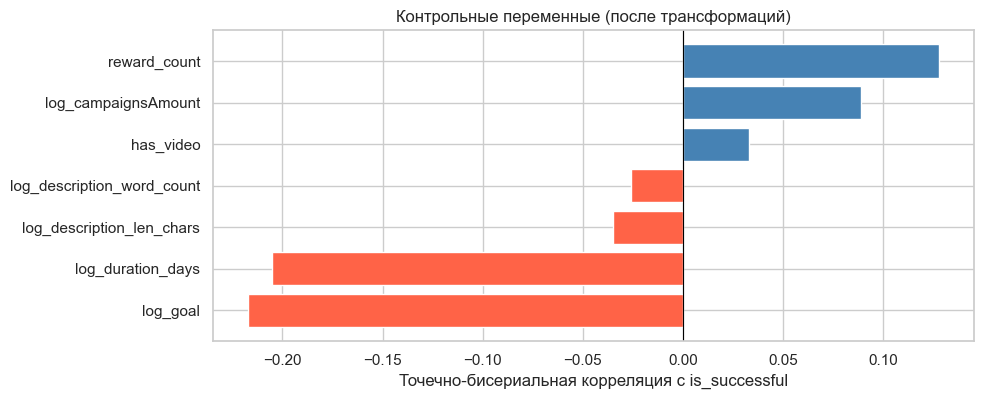

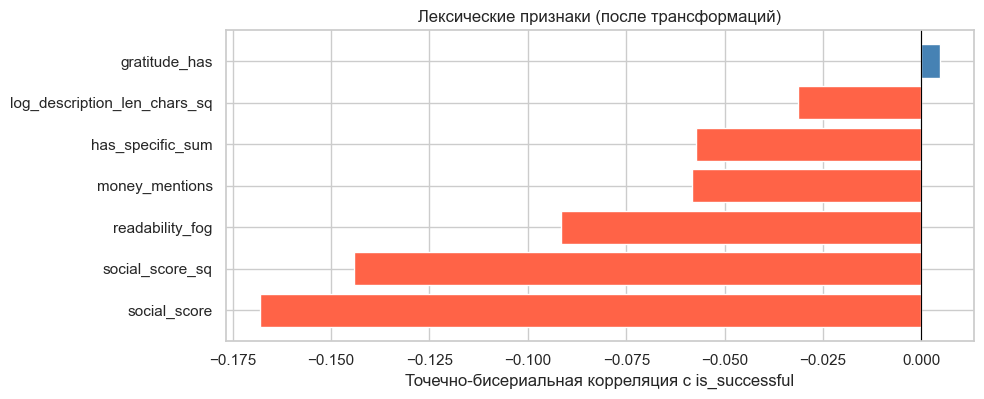

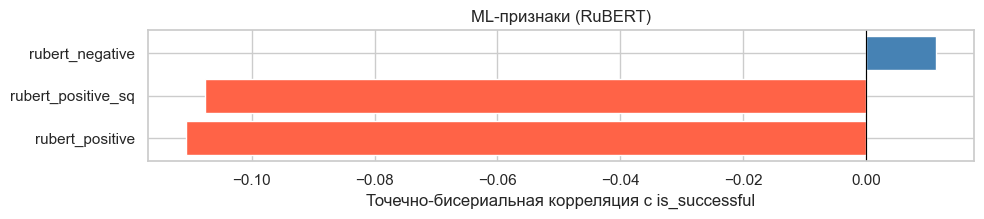

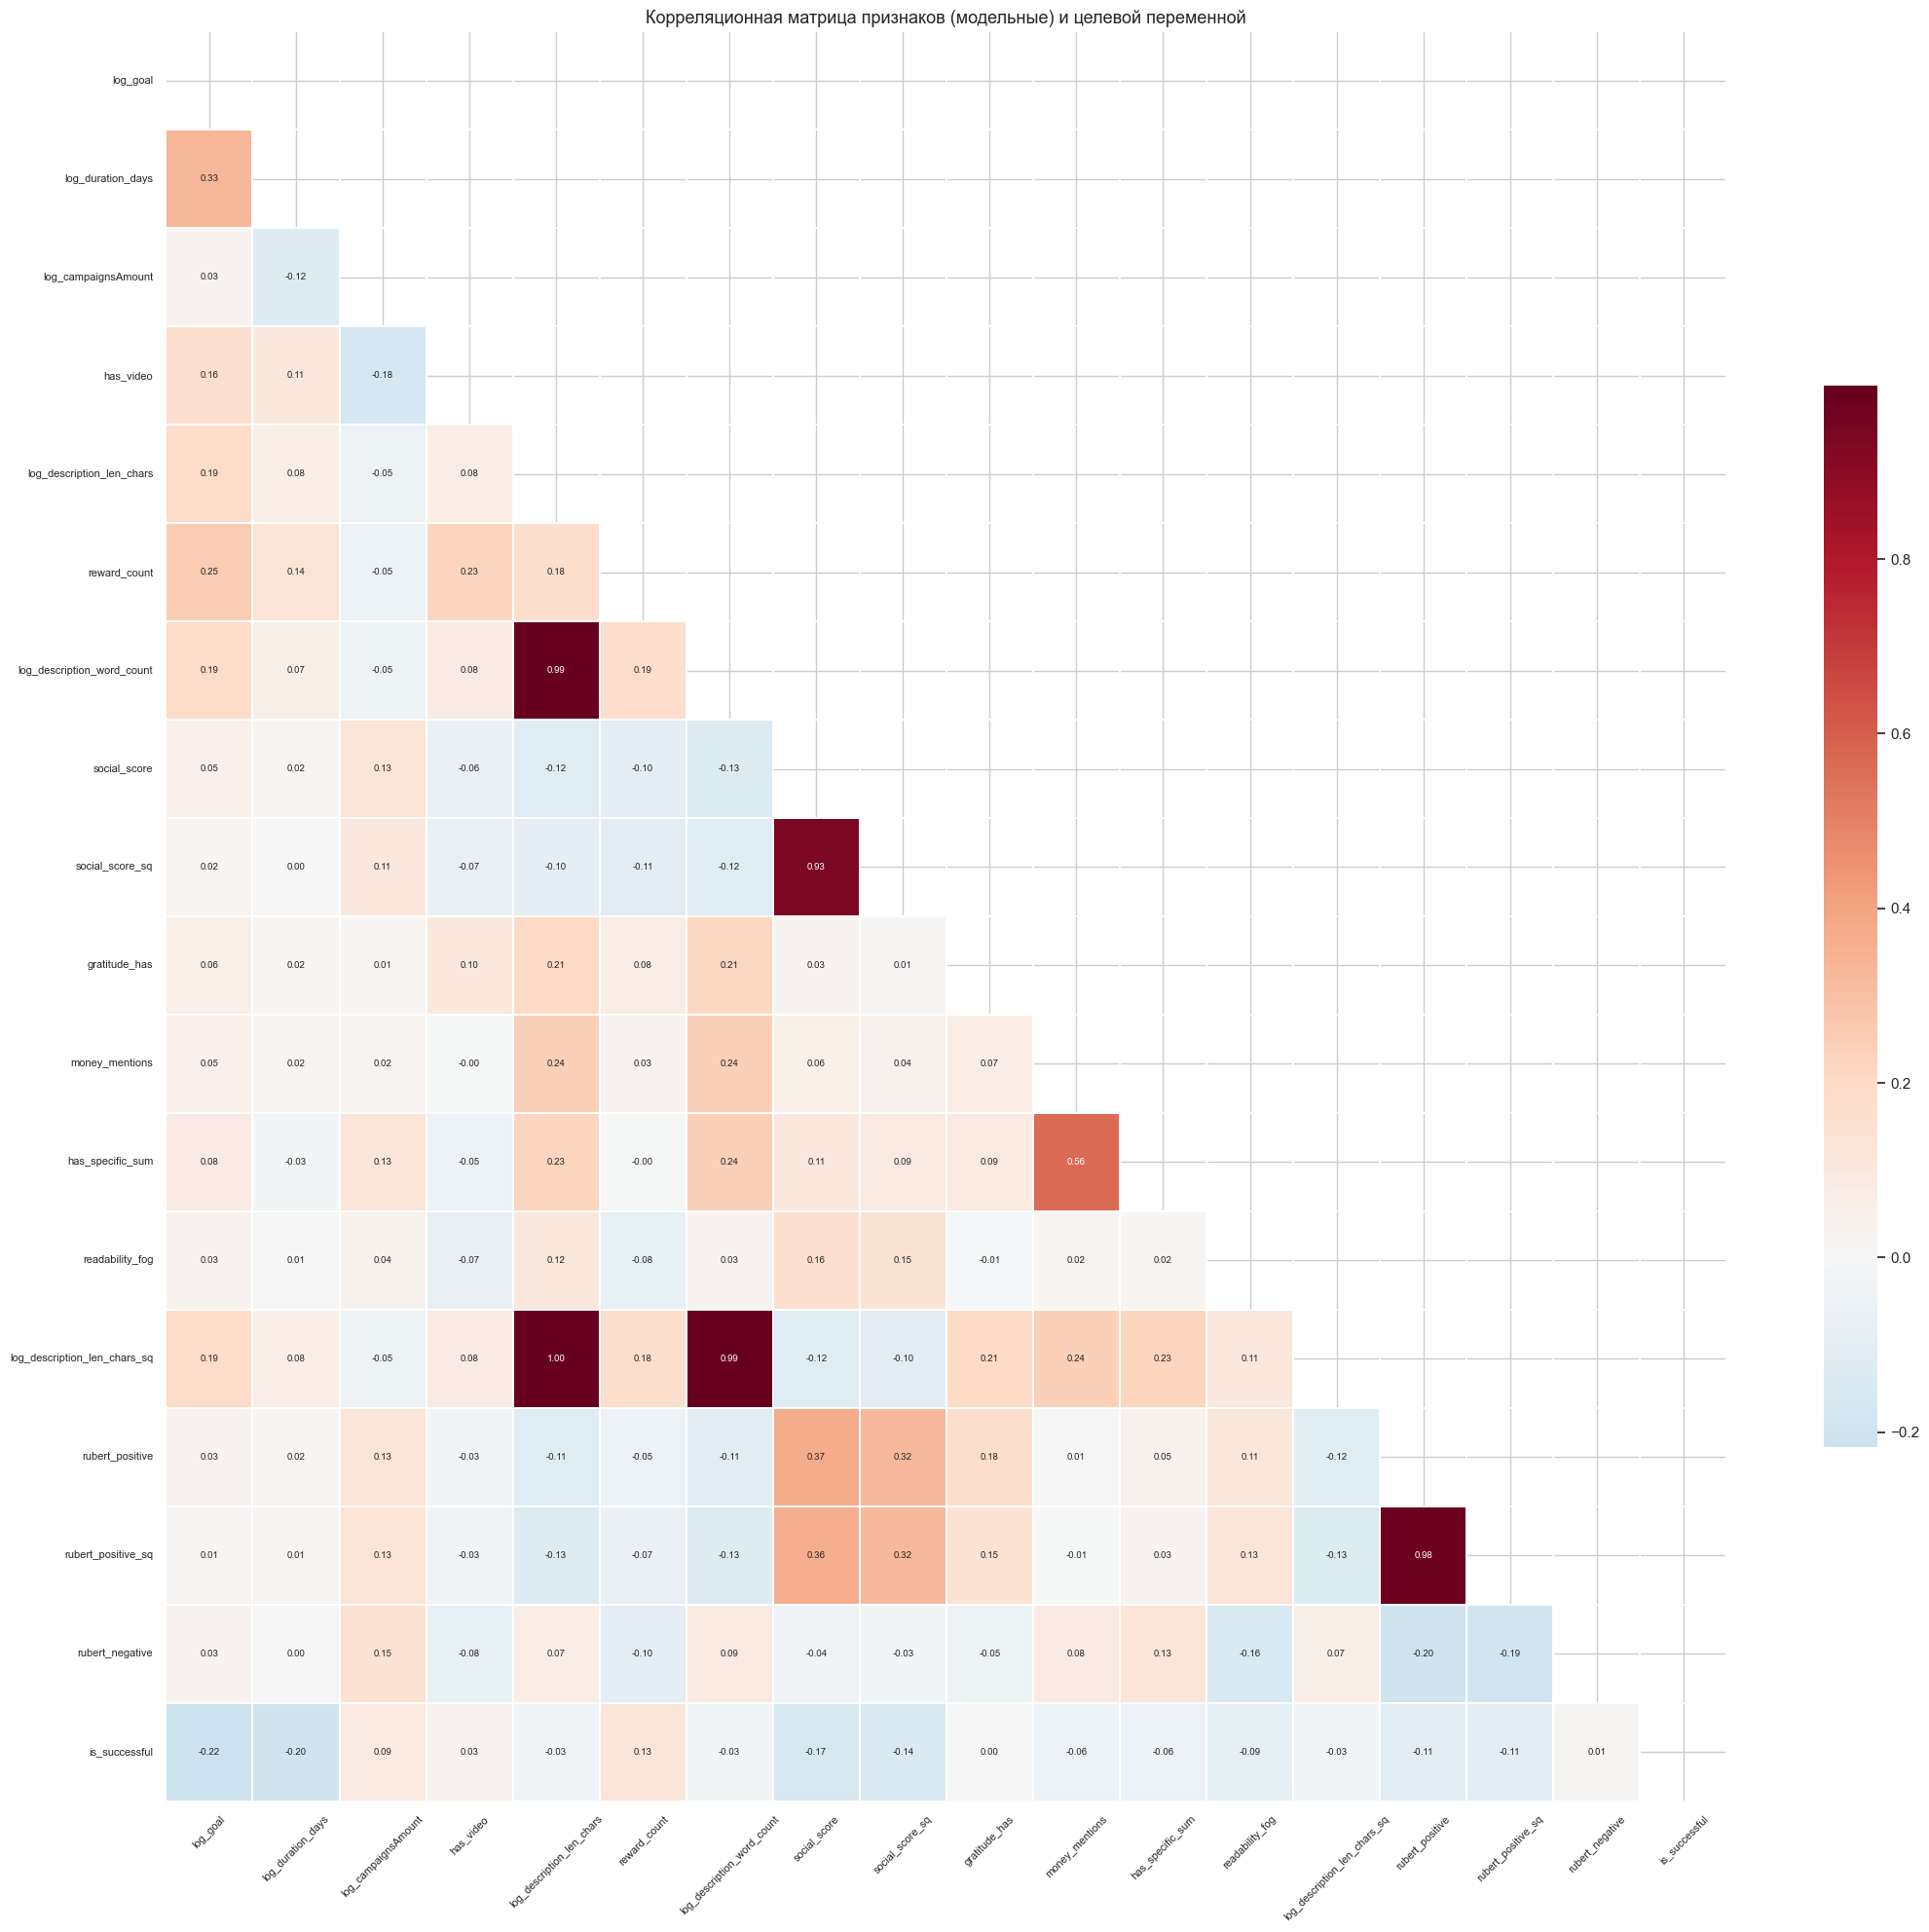

In [8]:
RAW_CONTROL = [
    'card.targetAmount.value',
    'campaign_duration_days',
    'counts.newsCount',
    'counts.commentsCount',
    'card.author.campaignsAmount',
    'video_count',
    'description_len_chars',
    'image_count',
    'reward_count',
    'description_word_count',
]

RAW_LEXICAL = [
    'social_score',
    'gratitude_score',
    'we_ratio',
    'i_ratio',
    'we_vs_i',
    'certainty_score',
    'uncertainty_score',
    'money_mentions',
    'number_density',
    'has_specific_sum',
    'readability_fog',
]

RAW_ML = [
    'rubert_positive',
    'rubert_negative',
]

MODEL_CONTROL = [
    'log_goal',
    'log_duration_days',
    'log_newsCount',
    'log_commentsCount',
    'log_campaignsAmount',
    'has_video',
    'log_video_count',
    'log_description_len_chars',
    'log_image_count',
    'reward_count',
    'log_description_word_count',
]

MODEL_LEXICAL = [
    'social_score',
    'social_score_sq',             
    'gratitude_has',
    'log_we_ratio',
    'log_i_ratio',
    'log_we_vs_i',
    'log_certainty_score',
    'log_uncertainty_score',
    'money_mentions',
    'log_number_density',
    'has_specific_sum',
    'readability_fog',
    'log_description_len_chars_sq',
]

MODEL_ML = [
    'rubert_positive',
    'rubert_positive_sq',          
    'rubert_negative',
]

CATEGORY_DUMMIES = [c for c in df.columns if c.startswith('cat_')]

TARGET = 'is_successful'

ALL_RAW   = RAW_CONTROL + RAW_LEXICAL + RAW_ML
ALL_MODEL = MODEL_CONTROL + MODEL_LEXICAL + MODEL_ML + CATEGORY_DUMMIES

FEATURE_LABELS = {
    'card.targetAmount.value':      'Целевая сумма (руб.)',
    'campaign_duration_days':       'Длительность кампании (дни)',
    'counts.newsCount':             'Кол-во новостей',
    'counts.commentsCount':         'Кол-во комментариев',
    'card.author.campaignsAmount':  'Кол-во кампаний автора',
    'video_count':                  'Кол-во видео',
    'description_len_chars':        'Длина описания (символы)',
    'image_count':                  'Кол-во изображений',
    'reward_count':                 'Кол-во вознаграждений',
    'description_word_count':       'Кол-во слов в описании',
    'social_score':                 'Социальный индекс',
    'gratitude_score':              'Индекс благодарности',
    'we_ratio':                     "Доля мест. 'мы'",
    'i_ratio':                      "Доля мест. 'я'",
    'we_vs_i':                      "Отношение мы/я (сглаж.)",
    'certainty_score':              'Индекс уверенности',
    'uncertainty_score':            'Индекс неуверенности',
    'money_mentions':               'Упоминания денег (кол-во)',
    'number_density':               'Плотность чисел',
    'has_specific_sum':             'Есть конкретная сумма (дамми)',
    'readability_fog':              'Индекс читаемости (Fog)',
    'rubert_positive':              'RuBERT: позитивность',
    'rubert_negative':              'RuBERT: негативность',
}

TRANSFORMATIONS = {
    'card.targetAmount.value':      'log (clip lower=1)',
    'campaign_duration_days':       'log',
    'counts.newsCount':             'log1p',
    'counts.commentsCount':         'log1p',
    'card.author.campaignsAmount':  'log',
    'video_count':                  'has_video (дамми) + log1p',
    'description_len_chars':        'log (clip lower=1) + квадрат',
    'image_count':                  'log1p',
    'reward_count':                 '—',
    'description_word_count':       'log',
    'social_score':                 '— + квадрат (GAM: ∩)',
    'gratitude_score':              'has_gratitude (дамми)',
    'we_ratio':                     'log1p',
    'i_ratio':                      'log1p',
    'we_vs_i':                      'log1p',
    'certainty_score':              'log1p',
    'uncertainty_score':            'log1p',
    'money_mentions':               '—',
    'number_density':               'log1p',
    'has_specific_sum':             '— (бинарный)',
    'readability_fog':              '—',
    'rubert_positive':              '— + квадрат (GAM: ↘ после 0.4)',
    'rubert_negative':              '—',
}

def descriptive_stats(df, features, labels=FEATURE_LABELS, transforms=TRANSFORMATIONS):
    rows = []
    for col in features:
        if col not in df.columns:
            continue
        s = df[col].fillna(0)
        q = s.quantile([0.25, 0.5, 0.75])
        rows.append({
            'Признак':         labels.get(col, col),
            'N':               int(s.notna().sum()),
            'Mean':            round(s.mean(), 4),
            'Std':             round(s.std(), 4),
            'Min':             round(s.min(), 4),
            'Q25':             round(q[0.25], 4),
            'Median':          round(q[0.50], 4),
            'Q75':             round(q[0.75], 4),
            'Max':             round(s.max(), 4),
            '% нулей':         round((s == 0).mean() * 100, 1),
            'Mean (успех=0)':  round(df.loc[df[TARGET]==0, col].mean(), 4),
            'Mean (успех=1)':  round(df.loc[df[TARGET]==1, col].mean(), 4),
            'Трансформация':   transforms.get(col, '—'),
        })
    return pd.DataFrame(rows).set_index('Признак')


desc_control = descriptive_stats(df, RAW_CONTROL)
desc_lexical = descriptive_stats(df, RAW_LEXICAL)
desc_ml      = descriptive_stats(df, RAW_ML)

for name, tbl in [('Контрольные', desc_control),
                  ('Лексические', desc_lexical),
                  ('ML-признаки', desc_ml)]:
    print(f"\n=== {name} ===")
    print(tbl.to_string())

def correlation_with_target(df, features, target=TARGET):
    rows = []
    for col in features:
        if col not in df.columns:
            continue
        s = df[col].fillna(0)
        r, p_pearson = stats.pointbiserialr(df[target], s)
        g0 = df.loc[df[target] == 0, col].dropna()
        g1 = df.loc[df[target] == 1, col].dropna()
        t_stat, p_ttest = stats.ttest_ind(g0, g1, equal_var=False)
        rows.append({
            'Признак':         col,
            'r (т-бис)':       round(r, 4),
            'p (Pearson)':     round(p_pearson, 4),
            't-статистика':    round(t_stat, 4),
            'p (t-тест)':      round(p_ttest, 4),
            'Значим (p<0.05)': 'да' if p_ttest < 0.05 else 'нет',
        })
    return (pd.DataFrame(rows)
            .set_index('Признак')
            .sort_values('r (т-бис)', ascending=False))


corr_control = correlation_with_target(df, MODEL_CONTROL)
corr_lexical = correlation_with_target(df, MODEL_LEXICAL)
corr_ml      = correlation_with_target(df, MODEL_ML)
corr_all     = correlation_with_target(df, ALL_MODEL)

for name, tbl in [('Контрольные (модельные)', corr_control),
                  ('Лексические (модельные)', corr_lexical),
                  ('ML-признаки',             corr_ml)]:
    print(f"\n=== Корреляции — {name} ===")
    print(tbl.to_string())

def plot_correlations(corr_df, title):
    fig, ax = plt.subplots(figsize=(10, len(corr_df) * 0.45 + 1))
    colors = ['steelblue' if r >= 0 else 'tomato'
              for r in corr_df['r (т-бис)']]
    ax.barh(corr_df.index, corr_df['r (т-бис)'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Точечно-бисериальная корреляция с is_successful')
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_correlations(corr_control, 'Контрольные переменные (после трансформаций)')
plot_correlations(corr_lexical, 'Лексические признаки (после трансформаций)')
plot_correlations(corr_ml,      'ML-признаки (RuBERT)')

heatmap_features = MODEL_CONTROL + MODEL_LEXICAL + MODEL_ML + [TARGET]
heatmap_features = [f for f in heatmap_features if f in df.columns]
corr_matrix = df[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(22, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    annot_kws={'size': 7},
    cmap='RdBu_r', center=0,
    linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Корреляционная матрица признаков (модельные) и целевой переменной', fontsize=13)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

## 13. Наборы признаков

- **A (контроли + категориальные)**
- **B (контроли + категориальные + текст)** — все сразу (хотим посмотреть изменение метрик при добавлении текстовых фичей).
- **C (только текст)**
- **D (только контроли)**


In [9]:
CONTROLS = [
    "log_goal", 
    "log_duration_days",
    "log1p_newsCount", 
    "log1p_commentsCount",
    "log_campaignsAmount",
    "has_video",
    "reward_count",
]

TEXT = [
    "social_score",
    "has_gratitude",
    "has_specific_sum",
    "log1p_we_vs_i",
    "log1p_certainty_score",
    "log1p_uncertainty_score",
    "log1p_number_density",
    "readability_fog",
    "rubert_positive",
    "rubert_negative",
    "log_description_word_count",
]

def _avail(cols):
    return [c for c in cols if c in df.columns]


FEATURE_SETS = {
    "A_controls_and_categories":        _avail(CONTROLS + CATEGORY_DUMMIES), #+ YEAR_DUMMIES
    "B_all":             _avail(CONTROLS + CATEGORY_DUMMIES + TEXT), #+ YEAR_DUMMIES
    "C_only_text":             _avail(TEXT),
    "D_only_controls":   _avail(CONTROLS),
}
for name, feats in FEATURE_SETS.items():
    print(f"{name:20s} → {len(feats)} признаков")

A_controls_and_categories → 15 признаков
B_all                → 26 признаков
C_only_text          → 11 признаков
D_only_controls      → 7 признаков


## 14. Визуализации

1. Распределение таргета.
2. Бокс-плоты: ключевые текстовые признаки в разрезе `is_successful`.
3. Корреляционная матрица текстовых признаков + готовых числовых.
4. Корреляции с таргетом (Point-biserial через Pearson).


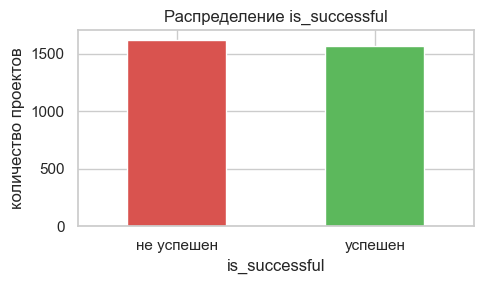

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))
df[TARGET_COL].value_counts().sort_index().plot.bar(ax=ax, color=["#d9534f", "#5cb85c"])
ax.set_xticklabels(["не успешен", "успешен"], rotation=0)
ax.set_title("Распределение is_successful")
ax.set_ylabel("количество проектов")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_distribution.png", dpi=120)
plt.show()


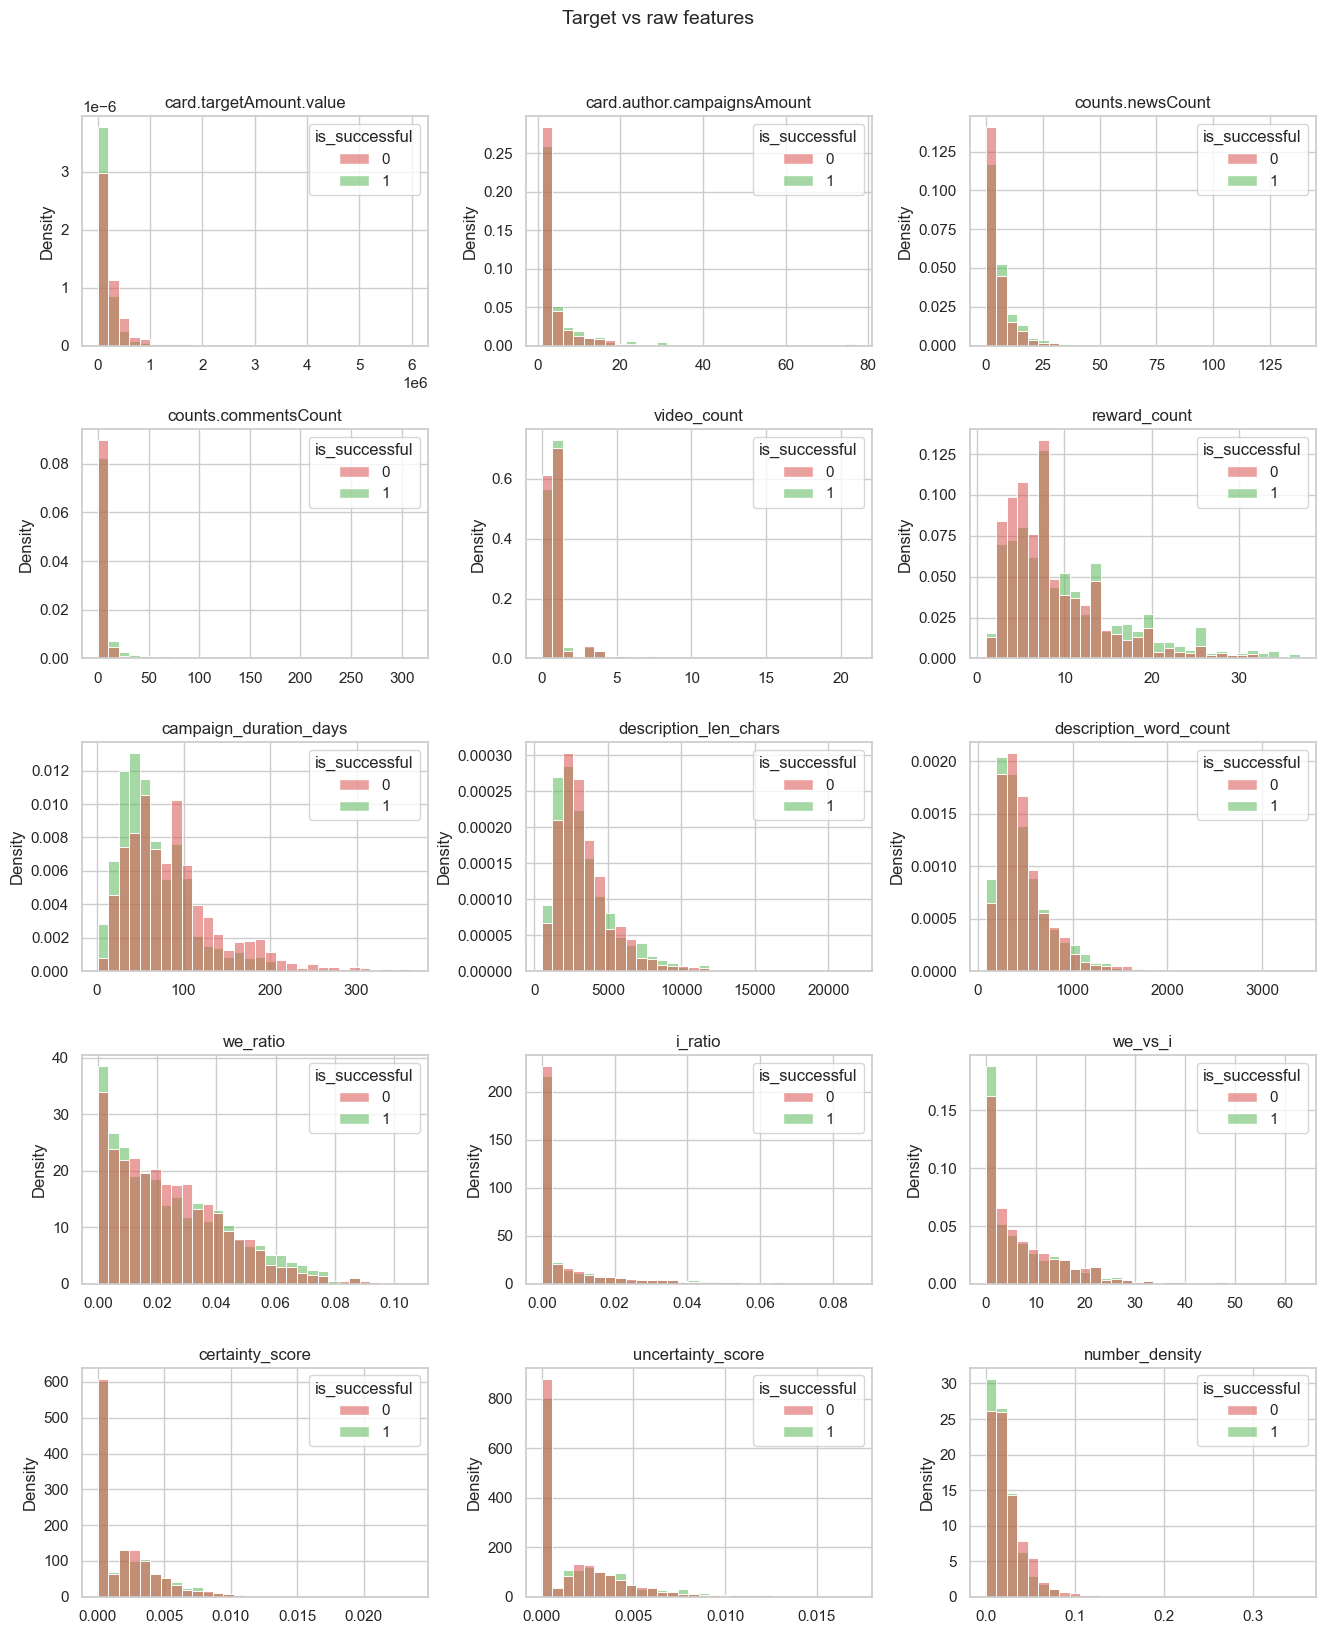

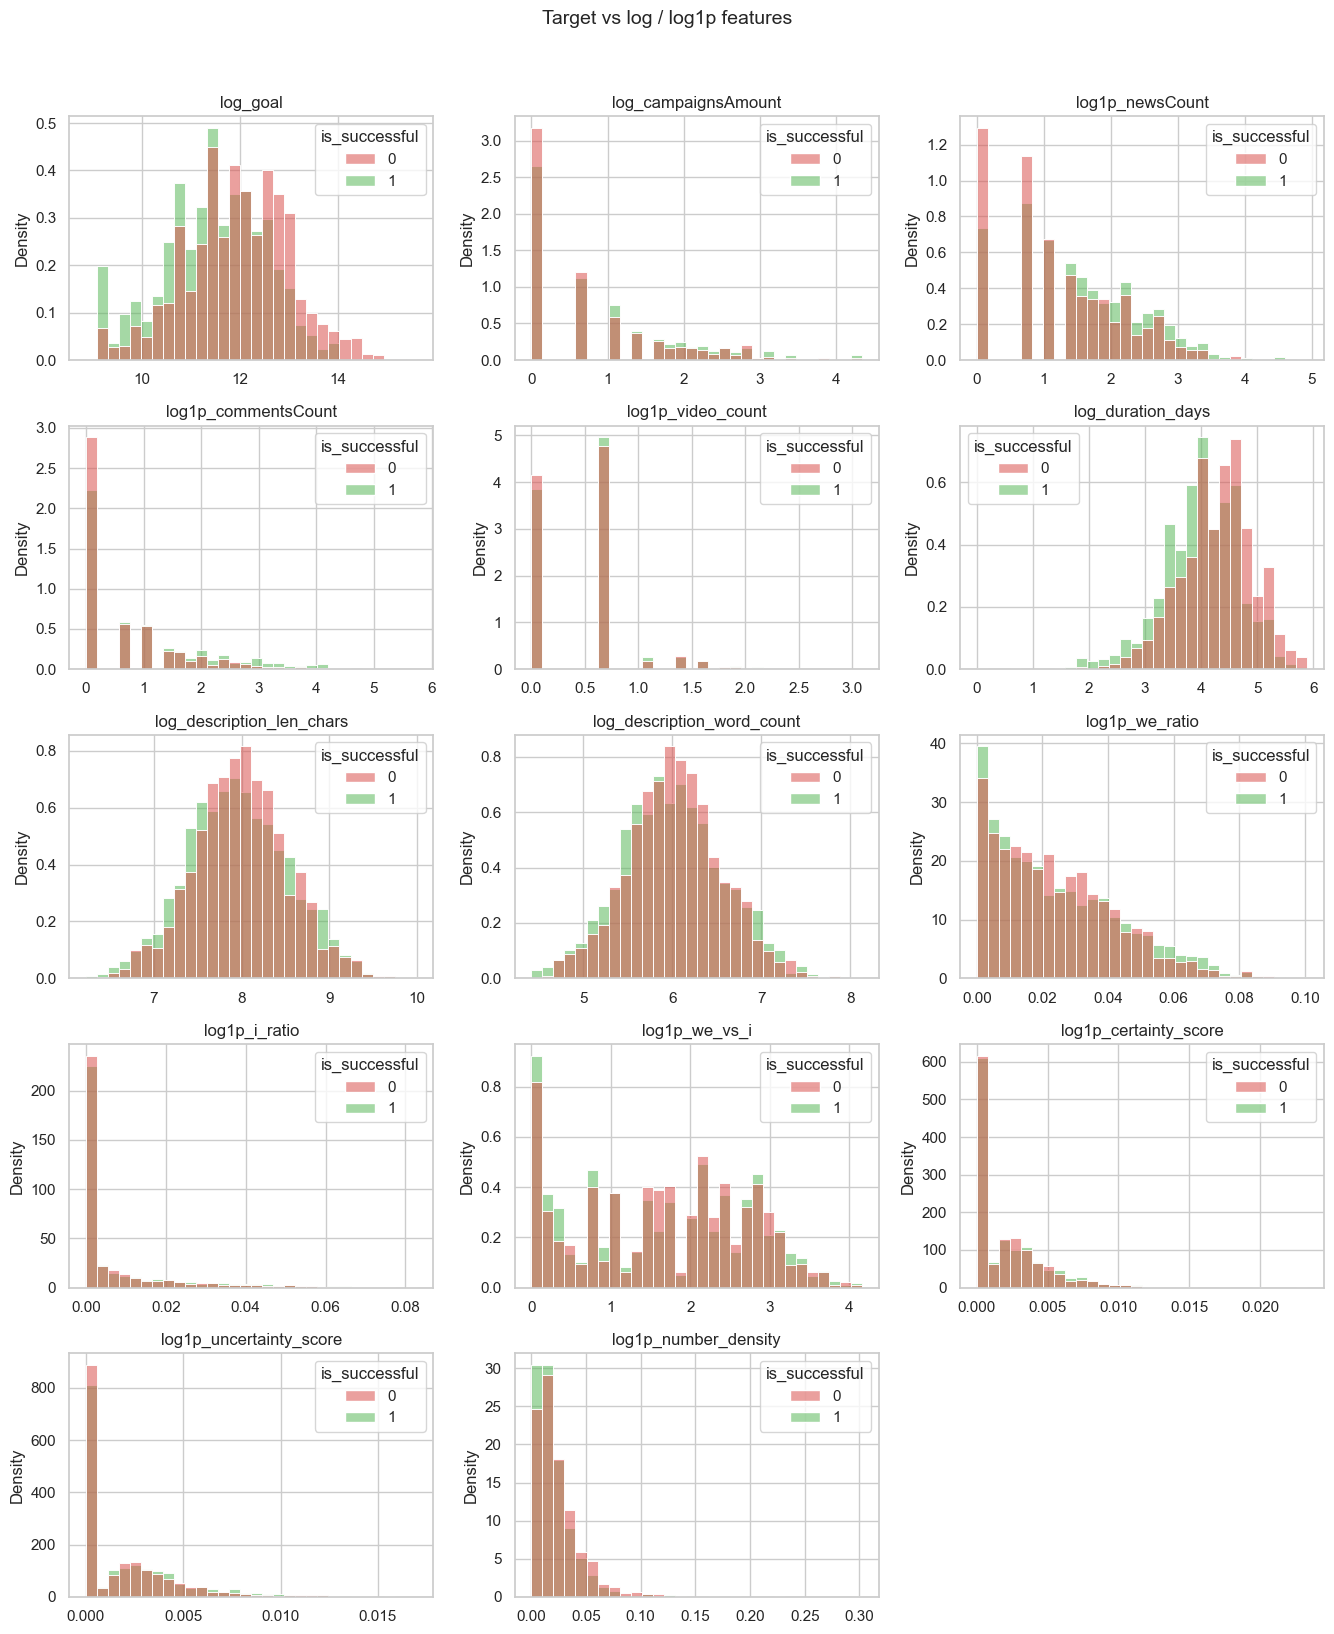

In [11]:
hist_feats_raw = [
    "card.targetAmount.value",
    "card.author.campaignsAmount",
    "counts.newsCount",
    "counts.commentsCount",
    "video_count",
    "reward_count",
    "campaign_duration_days",
    "description_len_chars",
    "description_word_count",
    "we_ratio",
    "i_ratio",
    "we_vs_i",
    "certainty_score",
    "uncertainty_score",
    "number_density",
]

hist_feats_log = [
    "log_goal",
    "log_campaignsAmount",
    "log1p_newsCount",
    "log1p_commentsCount",
    "log1p_video_count",
    "log_duration_days",
    "log_description_len_chars",
    "log_description_word_count",
    "log1p_we_ratio",
    "log1p_i_ratio",
    "log1p_we_vs_i",
    "log1p_certainty_score",
    "log1p_uncertainty_score",
    "log1p_number_density",
]

def plot_histograms_by_target(df, features, title, filename):
    features = [c for c in features if c in df.columns]

    if len(features) == 0:
        print(f"Нет доступных колонок для графика: {title}")
        return

    ncol = 3
    nrow = int(np.ceil(len(features) / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.2 * nrow))

    if nrow == 1 and ncol == 1:
        axes = np.array([axes])
    elif nrow == 1:
        axes = np.array([axes])

    for ax, f in zip(axes.flat, features):
        sns.histplot(
            data=df,
            x=f,
            hue=TARGET_COL,
            ax=ax,
            bins=30,
            stat="density",
            common_norm=False,
            palette=["#d9534f", "#5cb85c"],
            alpha=0.55
        )
        ax.set_title(f)
        ax.set_xlabel("")
        ax.set_ylabel("Density")

    for ax in axes.flat[len(features):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{filename}", dpi=120, bbox_inches="tight")
    plt.show()


plot_histograms_by_target(
    df=df,
    features=hist_feats_raw,
    title="Target vs raw features",
    filename="target_vs_raw_features_hist.png"
)

plot_histograms_by_target(
    df=df,
    features=hist_feats_log,
    title="Target vs log / log1p features",
    filename="target_vs_log_features_hist.png"
)


## 14. Проверка на мультиколлинеарность

In [12]:
df_fit = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

── VIF: CONTROLS + TEXT (без категориальных дамми) ──
                   feature      VIF
           rubert_positive 1.329876
              reward_count 1.308428
              social_score 1.296223
log_description_word_count 1.285048
                  log_goal 1.271258
           log1p_newsCount 1.256950
          has_specific_sum 1.254275
       log1p_commentsCount 1.238947
         log_duration_days 1.196692
           rubert_negative 1.161365
       log_campaignsAmount 1.154789
      log1p_number_density 1.152289
                 has_video 1.131094
             has_gratitude 1.112549
           readability_fog 1.103681
             log1p_we_vs_i 1.099301
   log1p_uncertainty_score 1.032263
     log1p_certainty_score 1.023616

✓  нет признаков с VIF > 10 — мультиколлинеарность в норме


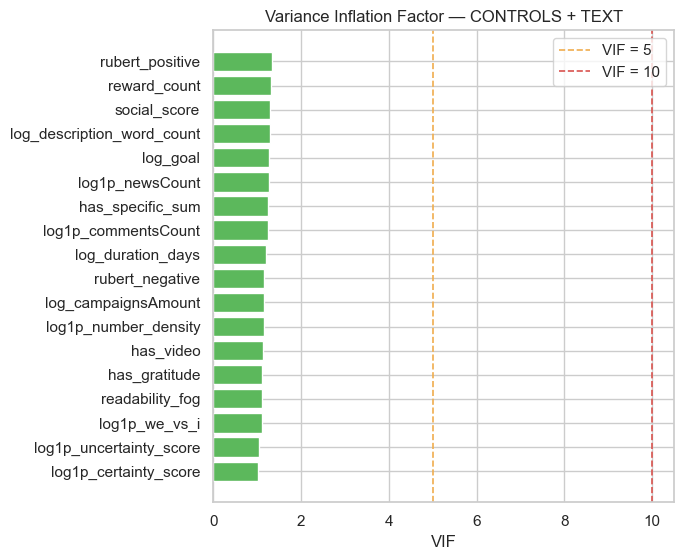

In [ ]:
def compute_vif(df_src: pd.DataFrame, features: list) -> pd.DataFrame:
    feats = [f for f in features if f in df_src.columns]
    X = (
        df_src[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    X = X.loc[:, X.nunique() > 1]
    Xc = sm.add_constant(X, has_constant="add")
    vif_vals = [
        variance_inflation_factor(Xc.values, i)
        for i in range(Xc.shape[1])
    ]
    return (
        pd.DataFrame({"feature": Xc.columns, "VIF": vif_vals})
        .query("feature != 'const'")
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

continuous_feats = [f for f in CONTROLS + TEXT if f in df_fit.columns]
vif_df = compute_vif(df_fit, continuous_feats)

print("── VIF: CONTROLS + TEXT (без категориальных дамми) ──")
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df["VIF"] > 10]
if not high_vif.empty:
    print(f"\nVIF > 10: {high_vif['feature'].tolist()}")
else:
    print("\n✓  нет признаков с VIF > 10 — мультиколлинеарность в норме")

fig, ax = plt.subplots(figsize=(7, max(4, 0.32 * len(vif_df))))
colors = [
    "#d9534f" if v > 10 else "#f0ad4e" if v > 5 else "#5cb85c"
    for v in vif_df["VIF"]
]
ax.barh(
    vif_df["feature"].iloc[::-1],
    vif_df["VIF"].iloc[::-1],
    color=list(reversed(colors))
)
ax.axvline(5,  color="#f0ad4e", lw=1.2, ls="--", label="VIF = 5")
ax.axvline(10, color="#d9534f", lw=1.2, ls="--", label="VIF = 10")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor — CONTROLS + TEXT")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Logit-регрессия

Таргет бинарный
Используем Logit с HC1-ошибками по нескольким спецификациям.


In [33]:
bool_cols = df_fit.select_dtypes(include="bool").columns.tolist()
df_fit[bool_cols] = df_fit[bool_cols].astype(int)
print(f"Сконвертировано bool→int: {len(bool_cols)} колонок")

y = df_fit[TARGET_COL].astype(int)

logit_results = {}

for name, feats in FEATURE_SETS.items():
    feats = [f for f in feats if f in df_fit.columns]

    print(f"\n{'─'*60}")
    print(f"[{name}] признаки ({len(feats)} шт.): {feats}")
    print(f"{'─'*60}")

    X = (
        df_fit[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")

    model = sm.Logit(y, X).fit(disp=0, maxiter=200, cov_type="HC1")

    print(model.summary())
    logit_results[name] = model

Сконвертировано bool→int: 0 колонок

────────────────────────────────────────────────────────────
[A_controls_and_categories] признаки (15 шт.): ['log_goal', 'log_duration_days', 'log1p_newsCount', 'log1p_commentsCount', 'log_campaignsAmount', 'has_video', 'reward_count', 'cat_Бизнес', 'cat_Досуг и события', 'cat_Литература', 'cat_Музыка', 'cat_Образование и просвещение', 'cat_Социальные', 'cat_Творческие (кино, театр, дизайн)', 'cat_Технологии']
────────────────────────────────────────────────────────────
                           Logit Regression Results                           
Dep. Variable:          is_successful   No. Observations:                 3192
Model:                          Logit   Df Residuals:                     3176
Method:                           MLE   Df Model:                           15
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.1581
Time:                        22:15:27   Log-Likelihood:                -1862.3
converged:    

## 16. Probit-регрессия

Альтернатива логиту: та же бинарная целевая `is_successful`, но ошибки задаются через нормальное CDF. Коэффициенты уже не интерпретируются как `log-odds`; сравниваем с логитом через AIC / pseudo R² и знак коэффициентов (должны совпадать).


In [34]:
probit_results = {}

for name, feats in FEATURE_SETS.items():
    feats = [f for f in feats if f in df_fit.columns]

    print(f"\n{'─'*60}")
    print(f"[{name}] признаки ({len(feats)} шт.): {feats}")
    print(f"{'─'*60}")

    X = (
        df_fit[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")

    model = sm.Probit(y, X).fit(disp=0, maxiter=200, cov_type="HC1")

    print(model.summary())
    probit_results[name] = model


print("\n── Logit vs Probit ──")
rows = []
for name in FEATURE_SETS:
    if name in logit_results and name in probit_results:
        L = logit_results[name]
        P = probit_results[name]
        rows.append({
            "набор":          name,
            "logit_R2":       round(L.prsquared, 3),
            "probit_R2":      round(P.prsquared, 3),
            "logit_AIC":      round(L.aic, 1),
            "probit_AIC":     round(P.aic, 1),
        })

print(pd.DataFrame(rows).to_string(index=False))


────────────────────────────────────────────────────────────
[A_controls_and_categories] признаки (15 шт.): ['log_goal', 'log_duration_days', 'log1p_newsCount', 'log1p_commentsCount', 'log_campaignsAmount', 'has_video', 'reward_count', 'cat_Бизнес', 'cat_Досуг и события', 'cat_Литература', 'cat_Музыка', 'cat_Образование и просвещение', 'cat_Социальные', 'cat_Творческие (кино, театр, дизайн)', 'cat_Технологии']
────────────────────────────────────────────────────────────
                          Probit Regression Results                           
Dep. Variable:          is_successful   No. Observations:                 3192
Model:                         Probit   Df Residuals:                     3176
Method:                           MLE   Df Model:                           15
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.1584
Time:                        22:15:47   Log-Likelihood:                -1861.7
converged:                       True   LL-Null:  

## 17. ML-модели

Одна и та же бинарная цель `is_successful`, пять моделей, четыре набора признаков. Валидация: Stratified K-Fold (или LOOCV при малом классе).


In [16]:
def make_models():
    models = {
        "LogReg_L1": Pipeline([
            ("sc",  StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l1", solver="saga",
                max_iter=5000, class_weight="balanced",
                random_state=RANDOM_STATE)),
        ]),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE,
            class_weight="balanced", n_jobs=-1),
        "GradBoost": GradientBoostingClassifier(
            n_estimators=200, max_depth=3,
            random_state=RANDOM_STATE),
    }

    try:
        from xgboost import XGBClassifier
        models["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=4,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1)
    except ImportError:
        print("XGBoost не установлен — пропускаем.")

    return models

def cv_splitter(y):
    min_class = y.value_counts().min()
    if len(y) < 30 or min_class < 5:
        return LeaveOneOut(), "LOOCV"
    n_splits = min(CV_FOLDS, min_class)
    return (StratifiedKFold(n_splits=n_splits, shuffle=True,
                            random_state=RANDOM_STATE),
            f"Stratified {n_splits}-Fold")


def eval_model(model, X, y, splitter):
    try:
        proba = cross_val_predict(
            model, X, y, cv=splitter, method="predict_proba"
        )[:, 1]
    except Exception as e:
        return {"ROC_AUC": np.nan, "PR_AUC": np.nan,
                "F1": np.nan, "Precision": np.nan,
                "Recall": np.nan, "error": str(e)}

    pred = (proba >= TEST_THRESHOLD).astype(int)

    return {
        "ROC_AUC":   roc_auc_score(y, proba)            if y.nunique() > 1 else np.nan,
        "PR_AUC":    average_precision_score(y, proba)  if y.nunique() > 1 else np.nan,
        "F1":        f1_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
        "error":     None,
    }

splitter, split_name = cv_splitter(y)
print(f"CV: {split_name}  "
      f"(n={len(y)}, min_class={y.value_counts().min()})\n")

valid_sets  = {k: v for k, v in FEATURE_SETS.items() if v}
model_names = list(make_models().keys())
total_iters = len(valid_sets) * len(model_names)

rows = []

with tqdm(total=total_iters, desc="ML grid", unit="run") as pbar:
    for set_name, feats in valid_sets.items():

        X = (df_fit[feats]
             .apply(pd.to_numeric, errors="coerce")
             .fillna(0)
             .astype(float))

        for m_name, model in make_models().items():
            pbar.set_postfix({"set": set_name, "model": m_name})

            metrics = eval_model(model, X, y, splitter)

            if metrics.get("error"):
                tqdm.write(f"  [!] {set_name} / {m_name}: {metrics['error']}")

            rows.append({
                "set":   set_name,
                "model": m_name,
                **{k: v for k, v in metrics.items() if k != "error"},
            })

            pbar.update(1)

results_table = (
    pd.DataFrame(rows)
    .sort_values(["set", "ROC_AUC"], ascending=[True, False])
    .reset_index(drop=True)
    .round(4)
)

best_per_set = (
    results_table
    .dropna(subset=["ROC_AUC"])
    .loc[results_table.groupby("set")["ROC_AUC"].idxmax()]
    .reset_index(drop=True)
)

print("\n Метрики")
print(results_table.to_string(index=False))

print("\n Лучшая модель по каждому набору признаков")
print(best_per_set.to_string(index=False))

CV: Stratified 5-Fold  (n=3192, min_class=1570)



ML grid: 100%|██████████| 16/16 [00:38<00:00,  2.43s/run, set=D_only_controls, model=XGBoost]              


 Метрики
                      set        model  ROC_AUC  PR_AUC     F1  Precision  Recall
A_controls_and_categories    LogReg_L1   0.7490  0.7176 0.6773     0.6671  0.6879
A_controls_and_categories    GradBoost   0.7360  0.7173 0.6652     0.6635  0.6669
A_controls_and_categories RandomForest   0.7229  0.6947 0.6457     0.6437  0.6478
A_controls_and_categories      XGBoost   0.7103  0.6930 0.6509     0.6516  0.6503
                    B_all    LogReg_L1   0.7537  0.7216 0.6829     0.6677  0.6987
                    B_all RandomForest   0.7501  0.7289 0.6825     0.6625  0.7038
                    B_all    GradBoost   0.7412  0.7273 0.6707     0.6644  0.6771
                    B_all      XGBoost   0.7331  0.7172 0.6652     0.6641  0.6662
              C_only_text RandomForest   0.6266  0.6081 0.5890     0.5708  0.6083
              C_only_text    LogReg_L1   0.6123  0.5769 0.6018     0.5659  0.6427
              C_only_text    GradBoost   0.6046  0.5781 0.5673     0.5627  0.5720
      

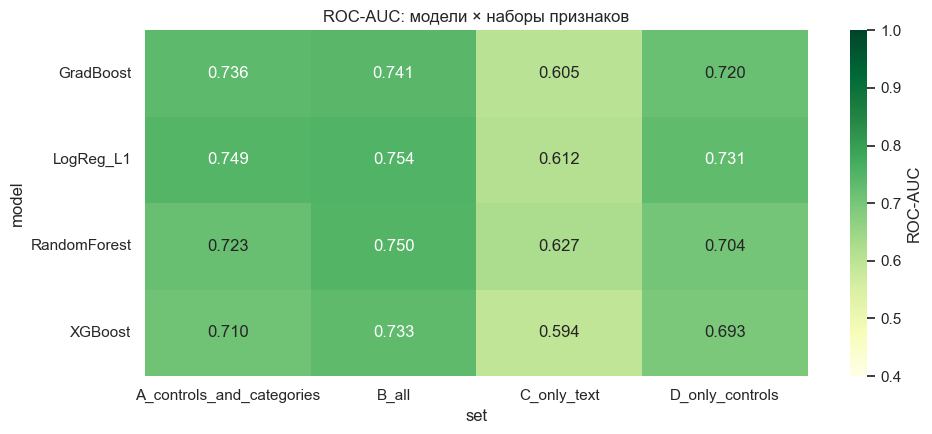

In [17]:
if "ROC_AUC" in results_table.columns:
    pivot = results_table.pivot(index="model", columns="set", values="ROC_AUC")
    plt.figure(figsize=(10, 4.5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn", vmin=0.4, vmax=1.0,
                cbar_kws={"label": "ROC-AUC"})
    plt.title("ROC-AUC: модели × наборы признаков")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/ml_comparison.png", dpi=120)
    plt.show()

## 18. SHAP

Берём RandomForest на полном наборе признаков B.


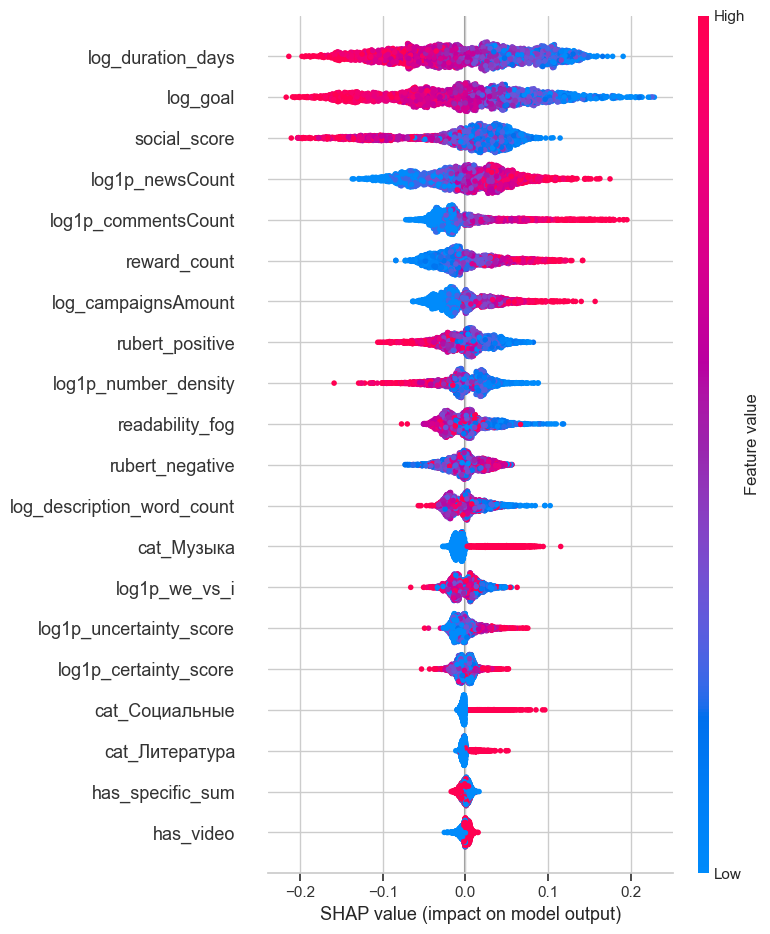

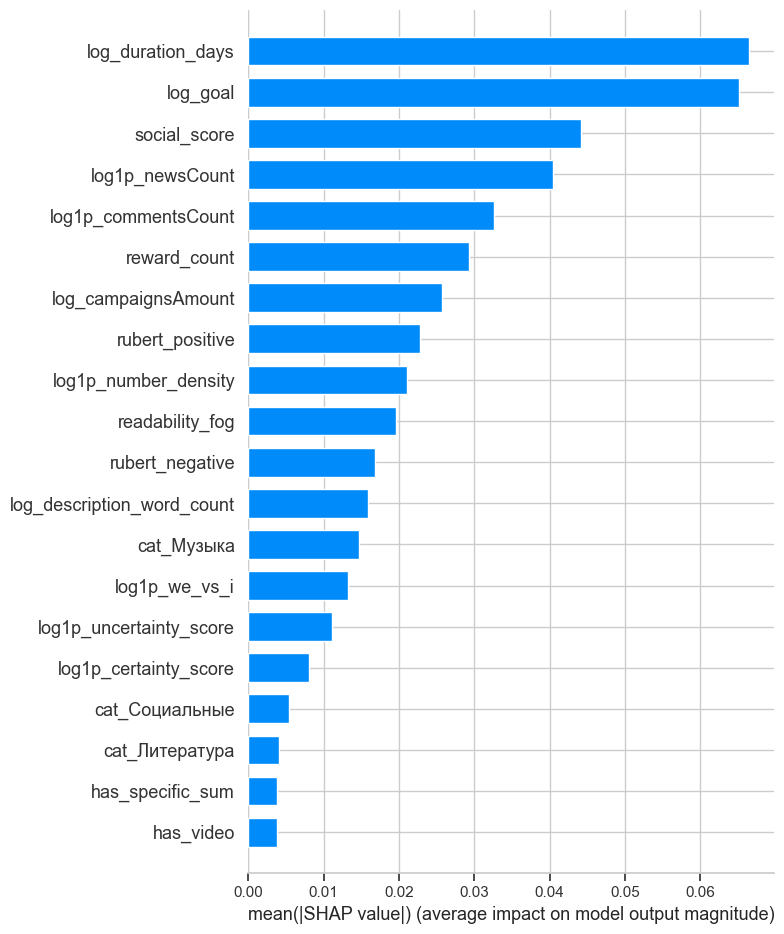

,mean_|SHAP|
log_duration_days,0.0665
log_goal,0.0651
social_score,0.0442
log1p_newsCount,0.0405
log1p_commentsCount,0.0326
reward_count,0.0294
log_campaignsAmount,0.0258
rubert_positive,0.0227
log1p_number_density,0.0211
readability_fog,0.0197


In [18]:
import shap

best_feats = FEATURE_SETS["B_all"]
X_shap = df_fit[best_feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                            class_weight="balanced")
rf.fit(X_shap, y)

explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X_shap)

if isinstance(sv, list):
    sv = sv[1]
sv = np.asarray(sv)
if sv.ndim == 3:
    sv = sv[:, :, 1]

plt.figure()
shap.summary_plot(sv, X_shap, show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

plt.figure()
shap.summary_plot(sv, X_shap, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_bar.png", dpi=120, bbox_inches="tight")
plt.show()

mean_abs = (pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns)
              .sort_values(ascending=False))
mean_abs.round(4).to_frame("mean_|SHAP|")

## 19. Категориальный таргет: `funding_bucket`

Дробим `funding_ratio` на три класса:

- `0` — провал (<0.5 от цели)
- `1` — частичный успех (0.5 — 1.0)
- `2` — полный сбор / оверфандинг (≥1.0)

Эти классы естественно упорядочены, поэтому прогоняем две модели:
1. **Multinomial logit** (`sm.MNLogit`) — не использует порядок.
2. **Ordered logit / ordered probit** (`OrderedModel`) — учитывает порядок.


funding_bucket распределение:
  0 · <0.5 (провал)         : 550 (17.2%)
  1 · 0.5–1 (частичный)     : 1072 (33.6%)
  2 · >=1 (успех)           : 1570 (49.2%)


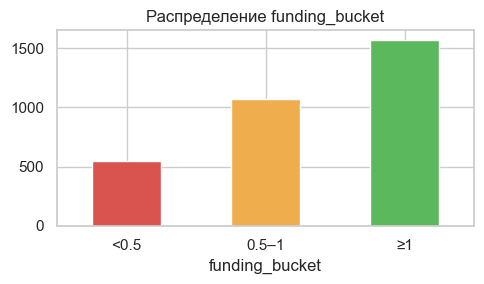

In [19]:
def make_funding_bucket(series: pd.Series) -> pd.Series:
    bins = [-np.inf, 0.5, 1.0, np.inf]
    labels = [0, 1, 2]  # 0: <0.5, 1: 0.5-1, 2: >=1
    return pd.cut(series, bins=bins, labels=labels, right=False).astype(int)


df_fit["funding_bucket"] = make_funding_bucket(df_fit["funding_ratio"].fillna(0))

bucket_counts = df_fit["funding_bucket"].value_counts().sort_index()
print("funding_bucket распределение:")
for k, v in bucket_counts.items():
    name = {0: "<0.5 (провал)", 1: "0.5–1 (частичный)", 2: ">=1 (успех)"}[k]
    print(f"  {k} · {name:22s}: {v:3d} ({v/len(df_fit)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
bucket_counts.plot.bar(ax=ax, color=["#d9534f", "#f0ad4e", "#5cb85c"])
ax.set_xticklabels(["<0.5", "0.5–1", "≥1"], rotation=0)
ax.set_title("Распределение funding_bucket")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/funding_bucket_distribution.png", dpi=120)
plt.show()


### 19.1 Multinomial Logit

Модель выбирает между тремя классами независимо. Базовая категория — `0` (провал). Коэффициенты интерпретируются как `log-odds` класса vs базовой.

In [20]:
def fit_mnlogit(X: pd.DataFrame, y: pd.Series, label: str):
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    if X.shape[1] >= len(y):
        print(f"[{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        model = sm.MNLogit(y, X).fit(method="bfgs", disp=0, maxiter=500)
    except Exception as e:
        print(f"[{label}] ошибка: {e}")
        return None
    print(f"\n══ MNLogit · {label} ══")
    print(f"  n={int(model.nobs)}  pseudo R²={model.prsquared:.3f}  "
          f"LLR p={model.llr_pvalue:.4g}  AIC={model.aic:.1f}")
    print(model.summary().as_text()[:3000])
    return model


y_bucket = df_fit["funding_bucket"].astype(int)
mnlogit_model = None

for name in ("A_controls_and_categories", "B_all"):
    feats = [f for f in FEATURE_SETS[name] if f in df_fit.columns]
    m = fit_mnlogit(df_fit[feats], y_bucket, name)
    if m is not None and name == "B_all":
        mnlogit_model = m


══ MNLogit · A_controls_and_categories ══
  n=3192  pseudo R²=0.341  LLR p=0  AIC=4349.4
                          MNLogit Regression Results                          
Dep. Variable:         funding_bucket   No. Observations:                 3192
Model:                        MNLogit   Df Residuals:                     3160
Method:                           MLE   Df Model:                           30
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.3409
Time:                        21:43:16   Log-Likelihood:                -2142.7
converged:                       True   LL-Null:                       -3250.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    funding_bucket=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    2.4153      1.084      2.22

### 19.2 Ordered Logit / Ordered Probit

Обе модели используют порядок классов (0 < 1 < 2). Отличаются только распределением латентной переменной: logit → логистическое, probit → нормальное. Сравниваем по AIC / log-likelihood.


In [21]:
def fit_ordered(X: pd.DataFrame, y: pd.Series, distr: str, label: str):
    X = (
        X.apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )

    X = X.loc[:, X.nunique() > 1]

    if X.shape[1] >= len(y) - 3:
        print(f"[{label}/{distr}] пропуск: слишком мало наблюдений")
        return None

    try:
        model = OrderedModel(y, X, distr=distr)
        result = model.fit(method="bfgs", disp=False, maxiter=300)
    except Exception as e:
        print(f"[{label}/{distr}] ошибка: {e}")
        return None

    print(f"\n\n{'=' * 80}")
    print(f"Ordered {distr.upper()} · {label}")
    print(f"{'=' * 80}")

    print(result.summary())

    return result


ordered_results = {}

feats = [f for f in FEATURE_SETS["B_all"] if f in df_fit.columns]

for distr in ("logit", "probit"):
    m = fit_ordered(
        df_fit[feats],
        y_bucket,
        distr=distr,
        label="B_all"
    )

    if m is not None:
        ordered_results[distr] = m


if len(ordered_results) == 2:
    print("\n\n" + "─" * 80)
    print("Ordered Logit vs Ordered Probit")
    print("─" * 80)

    comparison = pd.DataFrame({
        "distr": list(ordered_results.keys()),
        "AIC": [m.aic for m in ordered_results.values()],
        "BIC": [m.bic for m in ordered_results.values()],
        "LLF": [m.llf for m in ordered_results.values()],
        "nobs": [int(m.nobs) for m in ordered_results.values()],
    })

    print(comparison.round(3).to_string(index=False))



Ordered LOGIT · B_all
                             OrderedModel Results                             
Dep. Variable:         funding_bucket   Log-Likelihood:                -2554.4
Model:                   OrderedModel   AIC:                             5165.
Method:            Maximum Likelihood   BIC:                             5335.
Date:                Tue, 05 May 2026                                         
Time:                        21:43:20                                         
No. Observations:                3192                                         
Df Residuals:                    3164                                         
Df Model:                          26                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
log_goal                                -0.4632      0.

## 20. Train/test split - все, что ниже - не идет в основную работу

ML-модели выше оцениваются кросс-валидацией. Для последующих моделей (GAM, квантильная регрессия, интеракции) делаем один сплит 80/20.


In [22]:
TRAIN_SIZE = 0.8
_feats_all = [f for f in FEATURE_SETS["B_all"] if f in df_fit.columns]

train_idx, test_idx = tts(
    np.arange(len(df_fit)),
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_fit[TARGET_COL],
)
df_train = df_fit.iloc[train_idx].reset_index(drop=True)
df_test  = df_fit.iloc[test_idx].reset_index(drop=True)

y_train  = df_train[TARGET_COL].astype(int)
y_test   = df_test[TARGET_COL].astype(int)

print(f"train: {len(df_train)}  (успешных: {int(y_train.sum())})")
print(f"test : {len(df_test)}   (успешных: {int(y_test.sum())})")

train: 2553  (успешных: 1256)
test : 639   (успешных: 314)


## 21. Сплайны / GAM

Линейная регрессия в логите предполагает монотонную зависимость log-odds от предиктора. GAM: каждый признак заменяется на гладкую функцию, оцененную через penalized splines.

Используем `pygam.LogisticGAM`.

GAM признаки: ['log_goal', 'log_duration_days', 'log1p_newsCount', 'log1p_commentsCount', 'log_campaignsAmount', 'reward_count', 'social_score', 'log1p_we_vs_i', 'log1p_certainty_score', 'log1p_uncertainty_score', 'log1p_number_density', 'readability_fog', 'rubert_positive', 'rubert_negative', 'log_description_word_count']

GAM on test: ROC-AUC=0.782  ACC=0.707


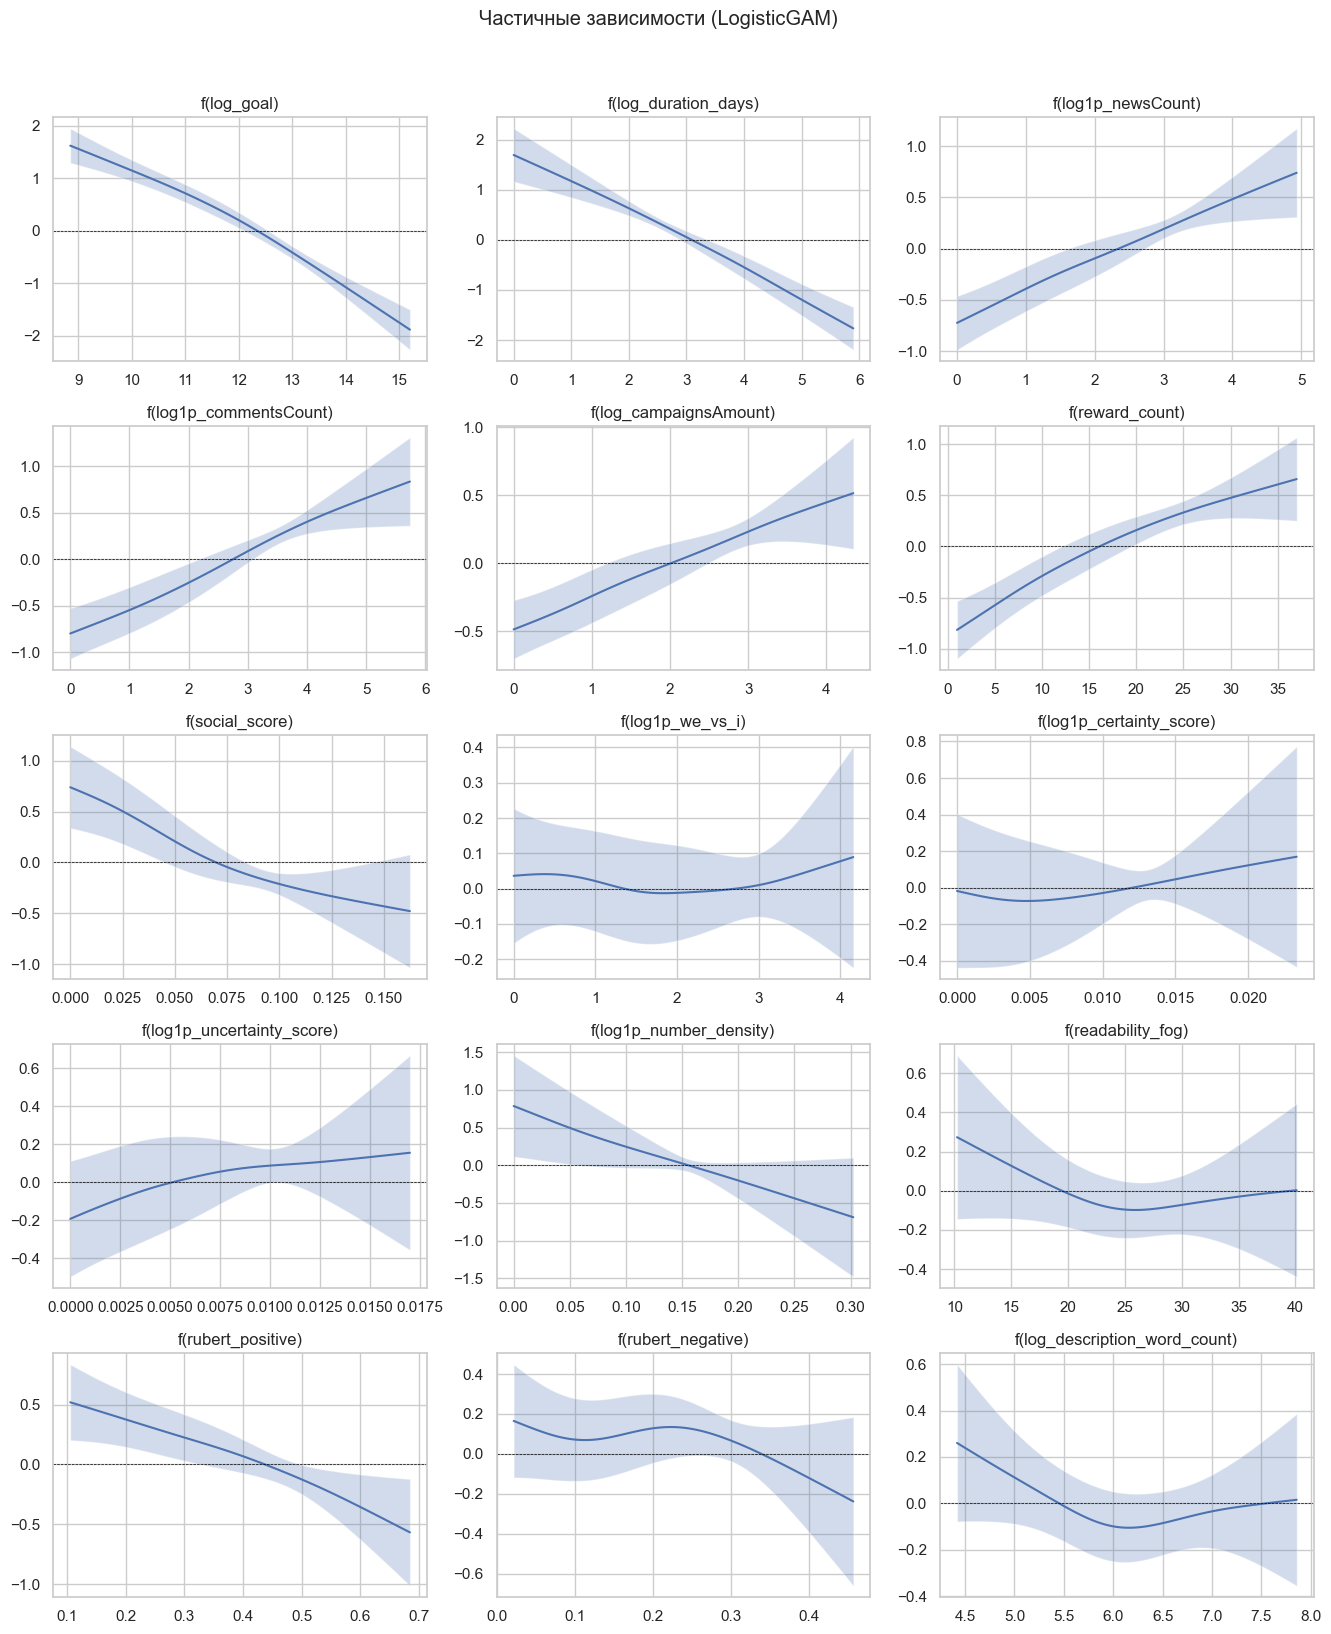

In [23]:
try:
    from pygam import LogisticGAM, s, f
    PYGAM_OK = True
except ImportError:
    PYGAM_OK = False
    print("pygam не установлен. Установи: pip install pygam")

GAM_FEATURES = [c for c in [
    "log_goal", 
    "log_duration_days",
    "log1p_newsCount", 
    "log1p_commentsCount",
    "log_campaignsAmount",
    "reward_count",
    "social_score",
    "log1p_we_vs_i",
    "log1p_certainty_score",
    "log1p_uncertainty_score",
    "log1p_number_density",
    "readability_fog",
    "rubert_positive",
    "rubert_negative",
    "log_description_word_count",
] if c in df_train.columns]

print(f"GAM признаки: {GAM_FEATURES}")

if PYGAM_OK and GAM_FEATURES:
    X_tr = df_train[GAM_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0).values
    X_te = df_test[GAM_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0).values

    terms = s(0)
    for i in range(1, len(GAM_FEATURES)):
        terms = terms + s(i)

    gam = LogisticGAM(terms).gridsearch(X_tr, y_train.values, progress=False)

    from sklearn.metrics import roc_auc_score, accuracy_score
    proba_te = gam.predict_proba(X_te)
    print(f"\nGAM on test: ROC-AUC={roc_auc_score(y_test, proba_te):.3f}  "
          f"ACC={accuracy_score(y_test, (proba_te >= 0.5).astype(int)):.3f}")

    # Частичные зависимости — где проявляется нелинейность
    n = len(GAM_FEATURES)
    ncol = 3
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.2 * nrow))
    for i, (ax, fname) in enumerate(zip(axes.flat, GAM_FEATURES)):
        XX = gam.generate_X_grid(term=i)
        pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
        ax.plot(XX[:, i], pdep)
        ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.25)
        ax.set_title(f"f({fname})")
        ax.axhline(0, color="black", lw=0.5, ls="--")
    for ax in axes.flat[len(GAM_FEATURES):]:
        ax.axis("off")
    plt.suptitle("Частичные зависимости (LogisticGAM)", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/gam_partial_dependence.png", dpi=120, bbox_inches="tight")
    plt.show()

## 22. Квантильная регрессия

Квантильная регрессия оценивает условные **квантили** `Q_τ(y | X)`.

Бежим по квантилям τ ∈ {0.1, 0.25, 0.5, 0.75, 0.9} на непрерывном `funding_ratio` и смотрим, как коэффициенты меняются вдоль распределения.


In [24]:
df_fit["log_funding_ratio"] = np.log1p(df_fit["funding_ratio"].clip(lower=0))

QUANT_FEATURES = [c for c in [
    "log_goal", "log_duration_days", "log_text_length", "has_video",
    "social_score", "gratitude_score", "we_ratio", "i_ratio",
    "certainty_score", "uncertainty_score",
    "number_density", "readability_fog",
    "rubert_positive", "rubert_negative",
] if c in df_fit.columns]

X_q = df_fit[QUANT_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
X_q = X_q.loc[:, X_q.nunique() > 1]
X_q = sm.add_constant(X_q, has_constant="add")
y_q = df_fit["log_funding_ratio"]

taus = [0.1, 0.25, 0.5, 0.75, 0.9]
quant_coefs = {}
for tau in taus:
    try:
        m = QuantReg(y_q, X_q).fit(q=tau, max_iter=2000)
        quant_coefs[tau] = m.params
    except Exception as e:
        print(f"tau={tau}: ошибка {e}")

coef_table = pd.DataFrame(quant_coefs).round(3)
print("Коэффициенты по квантилям:")
print(coef_table.to_string())

Коэффициенты по квантилям:
                    0.10   0.25   0.50   0.75   0.90
const              1.437  1.716  1.851  1.233  1.613
log_goal          -0.059 -0.056 -0.055 -0.024 -0.037
log_duration_days -0.009 -0.050 -0.065 -0.025 -0.044
has_video          0.071  0.066  0.044  0.018  0.039
social_score      -4.291 -4.709 -3.719 -1.097 -1.533
gratitude_score    6.783  7.175  4.065  1.326  7.175
we_ratio           0.371  0.791  0.273  0.142  0.370
i_ratio            1.421  0.245 -1.020 -0.341 -0.932
certainty_score    1.649  0.772 -1.023  0.656  3.183
uncertainty_score  2.671  3.100  4.940  2.234  4.869
number_density    -1.324 -1.317 -1.175 -0.365 -0.508
readability_fog   -0.005 -0.005 -0.006 -0.002 -0.003
rubert_positive   -0.609 -0.621 -0.310 -0.128 -0.250
rubert_negative   -0.726 -0.513 -0.216 -0.098 -0.208


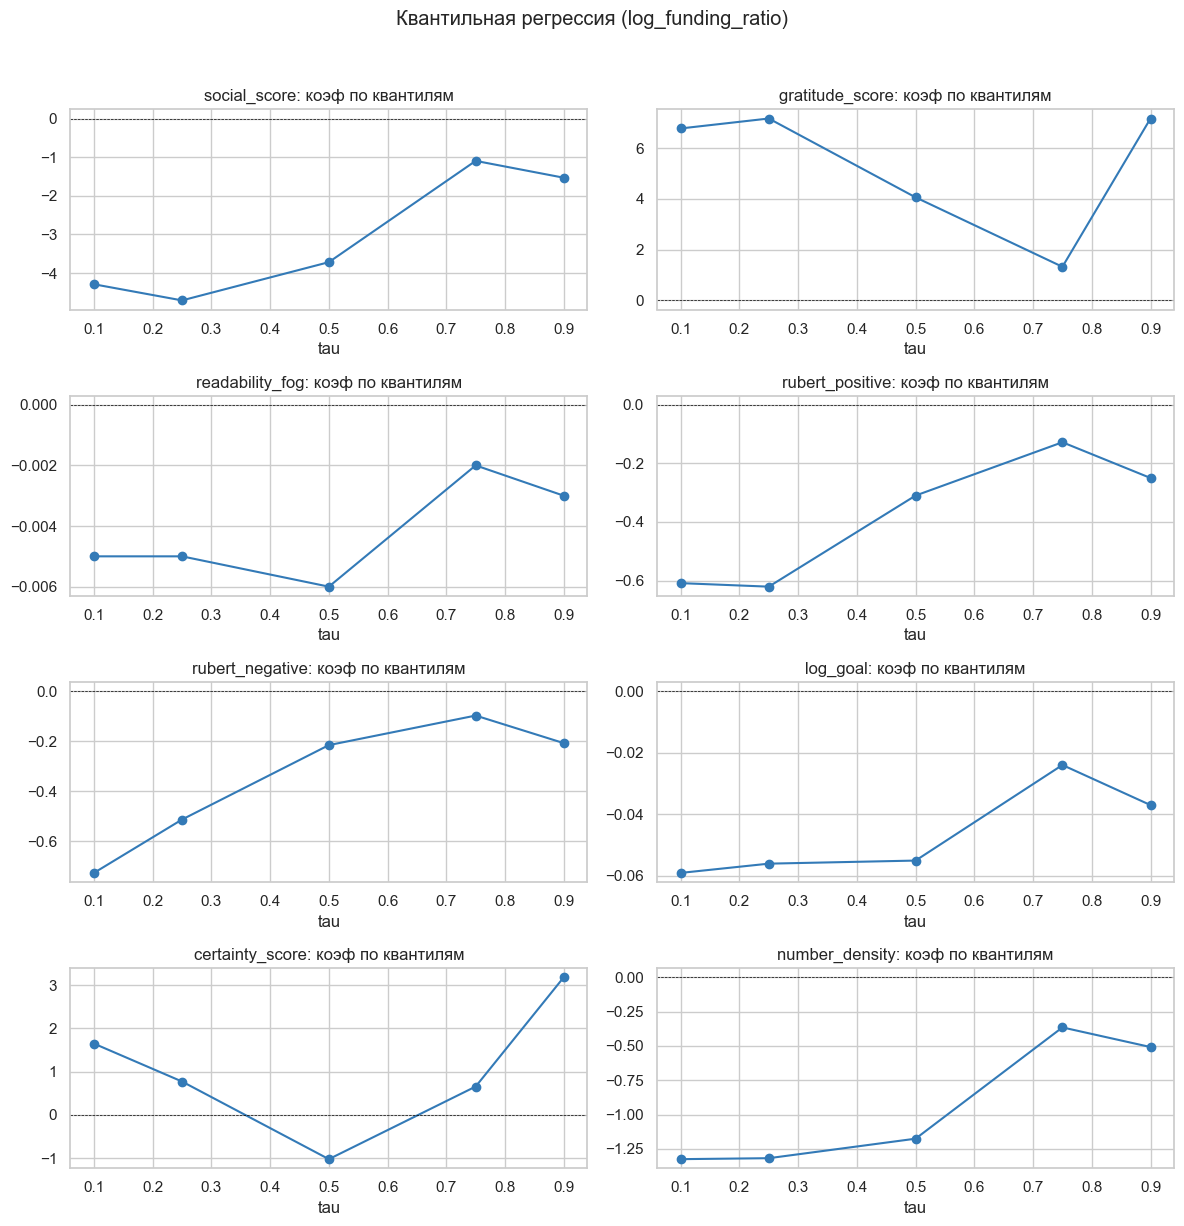

In [25]:
plot_feats = [c for c in ["social_score", "gratitude_score", "readability_fog",
                          "rubert_positive", "rubert_negative", "log_goal",
                          "certainty_score", "number_density"]
              if c in coef_table.index]

ncol = 2
nrow = int(np.ceil(len(plot_feats) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 3 * nrow))
for ax, f in zip(axes.flat, plot_feats):
    vals = coef_table.loc[f]
    ax.plot(vals.index, vals.values, marker="o", color="#337ab7")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_title(f"{f}: коэф по квантилям")
    ax.set_xlabel("tau")
for ax in axes.flat[len(plot_feats):]:
    ax.axis("off")
plt.suptitle("Квантильная регрессия (log_funding_ratio)", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quantile_coefs.png", dpi=120, bbox_inches="tight")
plt.show()

## 23. Двухчастная модель

1. **Часть 1 (селекция)**
   `P(funding_ratio ≥ 1 | X)` — логит/пробит.
   По сути это `is_successful`.

2. **Часть 2 (интенсивность)**
   Среди `funding_ratio ≥ 1`:
   `E[log(funding_ratio) | funding_ratio ≥ 1, X]` — OLS на лог-шкале.

Дополнительно смотрим две подгруппы:

- **Среди неуспешных** (`funding_ratio < 1`): что коррелирует с приближением к 1 (OLS на `funding_ratio` в [0, 1)).
- **Среди успешных** (`funding_ratio ≥ 1`): что связано с оверфандингом (OLS на `log(funding_ratio)`, где 0 ⇔ ровно 100%).


всего: 3192
  funding_ratio < 1 : 1622 (50.8%)
  funding_ratio ≥ 1 : 1570 (49.2%)


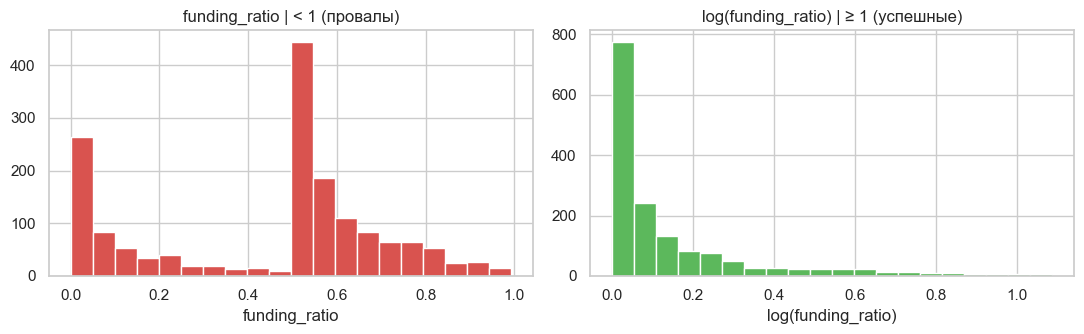

In [26]:
df_fit["funding_ratio"] = df_fit["funding_ratio"].fillna(0).clip(lower=0)
df_fit["success_binary"] = (df_fit["funding_ratio"] >= 1).astype(int)

n_total = len(df_fit)
n_succ = int(df_fit["success_binary"].sum())
n_fail = n_total - n_succ
print(f"всего: {n_total}")
print(f"  funding_ratio < 1 : {n_fail} ({n_fail/n_total*100:.1f}%)")
print(f"  funding_ratio ≥ 1 : {n_succ} ({n_succ/n_total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df_fit.loc[df_fit["success_binary"] == 0, "funding_ratio"],
             bins=20, color="#d9534f", edgecolor="white")
axes[0].set_title("funding_ratio | < 1 (провалы)")
axes[0].set_xlabel("funding_ratio")

succ_vals = df_fit.loc[df_fit["success_binary"] == 1, "funding_ratio"]
axes[1].hist(np.log(succ_vals.clip(lower=1e-6)),
             bins=20, color="#5cb85c", edgecolor="white")
axes[1].set_title("log(funding_ratio) | ≥ 1 (успешные)")
axes[1].set_xlabel("log(funding_ratio)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/hurdle_distributions.png", dpi=120)
plt.show()


### 23.1 Часть 1 — селекция: `P(funding_ratio ≥ 1 | X)`

Логит на всех `n` наблюдениях. Набор признаков — `B_all` (контроли + категории + годы + текст).


In [27]:
def fit_hurdle_part1(df, feats, label="B_all"):
    X = df[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = df["success_binary"].astype(int)
    if X.shape[1] >= len(y):
        print(f"[part1/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
        
    try:
        m = sm.Logit(y, X).fit(disp=0, cov_type="HC1", maxiter=300)
    except Exception as e:
        print(f"[part1/{label}] ошибка: {e}")
        return None
    print(f"\n══ Hurdle · Part 1 (selection) · {label} ══")
    print(f"  n={int(m.nobs)}  pseudo R²={m.prsquared:.3f}  AIC={m.aic:.1f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "z": m.tvalues, "p": m.pvalues,
        "OR": np.exp(m.params),
    }).round(4)
    print(summ.sort_values("p").to_string())
    return m


feats_all = [f for f in FEATURE_SETS["B_all"] if f in df_fit.columns]
hurdle_part1 = fit_hurdle_part1(df_fit, feats_all, label="B_all")



══ Hurdle · Part 1 (selection) · B_all ══
  n=3192  pseudo R²=0.168  AIC=3736.9
                                         coef       se        z       p            OR
const                                  7.1707   0.7802   9.1914  0.0000  1.300809e+03
cat_Образование и просвещение          1.1822   0.2675   4.4199  0.0000  3.261400e+00
cat_Музыка                             1.0788   0.1661   6.4967  0.0000  2.941100e+00
cat_Литература                         0.8575   0.1593   5.3829  0.0000  2.357100e+00
reward_count                           0.0380   0.0072   5.2494  0.0000  1.038700e+00
cat_Социальные                         1.1333   0.1711   6.6256  0.0000  3.106000e+00
log1p_commentsCount                    0.2441   0.0419   5.8259  0.0000  1.276500e+00
log1p_newsCount                        0.3270   0.0467   7.0007  0.0000  1.386800e+00
log_duration_days                     -0.6877   0.0718  -9.5812  0.0000  5.027000e-01
log_goal                              -0.4552   0.0453 -10.

### 23.2 Часть 2 — интенсивность среди успешных: `E[log(funding_ratio) | funding_ratio ≥ 1]`

OLS с HC1 на подвыборке `success_binary == 1`. Цель — `log(funding_ratio)`; 0 означает «ровно 100%», положительные значения — оверфандинг.


In [28]:
def fit_hurdle_part2(df, feats, label="B_all"):
    sub = df[df["success_binary"] == 1].copy()
    sub["log_fr"] = np.log(sub["funding_ratio"].clip(lower=1e-6))

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["log_fr"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[part2/{label}] пропуск: n_успешных ({len(y)}) слишком мало для {X.shape[1]} предикторов")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[part2/{label}] ошибка: {e}")
        return None
    print(f"\n══ Hurdle · Part 2 (intensity | success) · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}  AIC={m.aic:.1f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4)
    print(summ.sort_values("p").to_string())
    return m


hurdle_part2 = fit_hurdle_part2(df_fit, feats_all, label="B_all")



══ Hurdle · Part 2 (intensity | success) · B_all ══
  n=1570  R²=0.116  adjR²=0.101  AIC=-610.2
                                        coef      se       t       p
const                                 0.4844  0.1074  4.5117  0.0000
log_goal                             -0.0325  0.0066 -4.8885  0.0000
log_duration_days                    -0.0338  0.0077 -4.4199  0.0000
log1p_commentsCount                   0.0281  0.0051  5.4673  0.0000
reward_count                          0.0040  0.0010  3.9575  0.0001
cat_Литература                        0.0847  0.0212  3.9918  0.0001
log_campaignsAmount                   0.0193  0.0057  3.3784  0.0007
cat_Образование и просвещение         0.0966  0.0329  2.9338  0.0033
cat_Музыка                            0.0617  0.0223  2.7623  0.0057
cat_Творческие (кино, театр, дизайн)  0.0535  0.0234  2.2856  0.0223
log1p_we_vs_i                         0.0117  0.0052  2.2466  0.0247
social_score                         -0.5255  0.2813 -1.8679  0.0618
has_gr

### 23.3 Среди неуспешных: что связано с приближением к 1?

OLS на подвыборке `funding_ratio < 1` с целевой переменной `funding_ratio` (≈ «насколько далеко не дотянули»). Положительный коэффициент → признак помогает приблизиться к 100% даже при провале.


In [29]:
def fit_failed_approach(df, feats, label="B_all"):
    sub = df[df["success_binary"] == 0].copy()
    if len(sub) < 10:
        print(f"[failed/{label}] пропуск: слишком мало неуспешных ({len(sub)})")
        return None

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["funding_ratio"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[failed/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[failed/{label}] ошибка: {e}")
        return None
    print(f"\n══ Среди неуспешных · приближение к 1 · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4)
    print(summ.sort_values("p").head(20).to_string())
    return m


failed_model = fit_failed_approach(df_fit, feats_all, label="B_all")



══ Среди неуспешных · приближение к 1 · B_all ══
  n=1622  R²=0.582  adjR²=0.575
                                        coef      se        t       p
const                                 0.6063  0.0891   6.8084  0.0000
cat_Технологии                        0.3650  0.0363  10.0441  0.0000
cat_Творческие (кино, театр, дизайн)  0.3480  0.0178  19.5203  0.0000
cat_Образование и просвещение         0.3157  0.0312  10.1318  0.0000
cat_Музыка                            0.3412  0.0188  18.1283  0.0000
cat_Литература                        0.3390  0.0178  19.0086  0.0000
cat_Досуг и события                   0.3829  0.0193  19.8823  0.0000
cat_Бизнес                            0.3552  0.0413   8.5941  0.0000
cat_Социальные                        0.3716  0.0172  21.5942  0.0000
log_campaignsAmount                   0.0316  0.0063   5.0463  0.0000
log1p_commentsCount                   0.0225  0.0049   4.6081  0.0000
log1p_newsCount                       0.0383  0.0051   7.5653  0.0000
log_goal

### 23.4 Среди успешных: что связано с оверфандингом?

OLS на подвыборке `funding_ratio ≥ 1` с `log(funding_ratio)` в качестве цели. В отличие от 24.2, здесь нас интересует именно знак и значимость коэффициентов — признаки «overfunding drivers».


In [30]:
def fit_overfunding(df, feats, label="B_all"):
    sub = df[df["success_binary"] == 1].copy()
    if len(sub) < 10:
        print(f"[over/{label}] пропуск: мало успешных ({len(sub)})")
        return None
    sub["log_fr"] = np.log(sub["funding_ratio"].clip(lower=1e-6))

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["log_fr"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[over/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[over/{label}] ошибка: {e}")
        return None
    print(f"\n══ Среди успешных · overfunding · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}")
    top = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4).sort_values("p")
    print(top.head(20).to_string())
    return m

overfund_model = fit_overfunding(df_fit, feats_all, label="B_all")



══ Среди успешных · overfunding · B_all ══
  n=1570  R²=0.116  adjR²=0.101
                                        coef      se       t       p
const                                 0.4844  0.1074  4.5117  0.0000
log_goal                             -0.0325  0.0066 -4.8885  0.0000
log_duration_days                    -0.0338  0.0077 -4.4199  0.0000
log1p_commentsCount                   0.0281  0.0051  5.4673  0.0000
reward_count                          0.0040  0.0010  3.9575  0.0001
cat_Литература                        0.0847  0.0212  3.9918  0.0001
log_campaignsAmount                   0.0193  0.0057  3.3784  0.0007
cat_Образование и просвещение         0.0966  0.0329  2.9338  0.0033
cat_Музыка                            0.0617  0.0223  2.7623  0.0057
cat_Творческие (кино, театр, дизайн)  0.0535  0.0234  2.2856  0.0223
log1p_we_vs_i                         0.0117  0.0052  2.2466  0.0247
social_score                         -0.5255  0.2813 -1.8679  0.0618
has_gratitude              

Коэффициенты: Part 1 (selection, log-odds) vs Part 2 (intensity, log_fr):
                                      part1_coef  part1_p  part2_coef  part2_p
log_goal                                  -0.455    0.000      -0.032    0.000
log_duration_days                         -0.688    0.000      -0.034    0.000
log1p_newsCount                            0.327    0.000       0.002    0.689
log1p_commentsCount                        0.244    0.000       0.028    0.000
log_campaignsAmount                        0.425    0.000       0.019    0.001
has_video                                  0.165    0.059       0.000    0.984
reward_count                               0.038    0.000       0.004    0.000
cat_Бизнес                                 1.330    0.013       0.059    0.141
cat_Досуг и события                        0.645    0.001       0.046    0.083
cat_Литература                             0.857    0.000       0.085    0.000
cat_Музыка                                 1.079    0.000

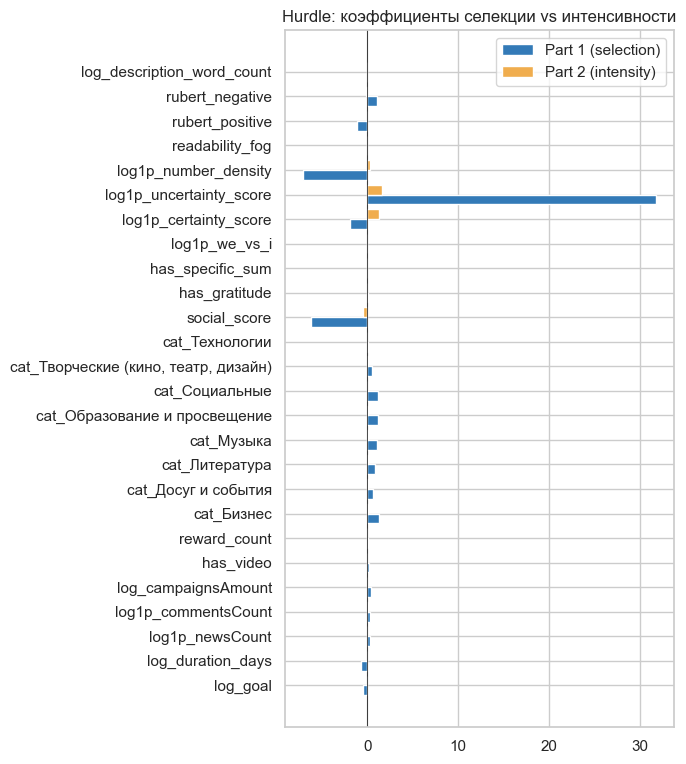

In [31]:
if hurdle_part1 is not None and hurdle_part2 is not None:
    common = [c for c in hurdle_part1.params.index
              if c in hurdle_part2.params.index and c != "const"]

    tbl = pd.DataFrame({
        "part1_coef":  hurdle_part1.params.loc[common],
        "part1_p":     hurdle_part1.pvalues.loc[common],
        "part2_coef":  hurdle_part2.params.loc[common],
        "part2_p":     hurdle_part2.pvalues.loc[common],
    }).round(3)
    print("Коэффициенты: Part 1 (selection, log-odds) vs Part 2 (intensity, log_fr):")
    print(tbl.to_string())

    plt.figure(figsize=(7, max(4, 0.3 * len(common))))
    idx = np.arange(len(common))
    plt.barh(idx - 0.2, tbl["part1_coef"], height=0.4,
             color="#337ab7", label="Part 1 (selection)")
    plt.barh(idx + 0.2, tbl["part2_coef"], height=0.4,
             color="#f0ad4e", label="Part 2 (intensity)")
    plt.yticks(idx, common)
    plt.axvline(0, color="black", lw=0.5)
    plt.legend()
    plt.title("Hurdle: коэффициенты селекции vs интенсивности")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/hurdle_coef_comparison.png", dpi=120)
    plt.show()
